## Section 1. Introduction to the Problem/Task

### Overview

  Childcare providers face a daily challenge: quickly identifying whether a sick child's symptoms match a communicable disease, understanding how that disease spreads, and knowing when the child should be excluded from the facility. Misinformation or delayed access to accurate disease information can lead to outbreaks that affect dozens of children and staff.

  This project addresses this challenge by building a **Retrieval-Augmented Generation (RAG) chatbot** powered by **Falcon-7B-Instruct**, a large open-source language model, grounded in a real-world childcare disease handbook published by the **New Hampshire Department of Health and Human Services**.

### Purpose and Domain

The chatbot is designed to serve as a **reliable, always-available reference assistant** for childcare providers. Its knowledge base is the *NH Disease Handbook for Childcare Providers* — a comprehensive reference document covering over 40 communicable diseases commonly encountered in childcare settings. The handbook includes fact sheets for each disease covering symptoms, transmission, incubation periods, exclusion criteria, treatment, and prevention.

### Real-World Significance

Building a retrieval-grounded conversational system for this domain is significant for several reasons:

- **Accuracy over generation**: Unlike a general LLM that may hallucinate medical facts, a RAG system grounds every answer in verified source documents, reducing the risk of dangerous misinformation.
- **Accessibility**: Childcare providers, many of whom are not medical professionals, benefit from natural-language access to complex disease information without needing to search lengthy PDF documents.
- **Scope control**: By restricting the knowledge base to the official handbook, the system declines to answer questions outside the document's scope, preventing overconfident responses on topics like specific drug dosages or hospital treatment protocols.
- **Practical deployment**: The system is deployed via a Gradio web interface accessible from any device, making it usable in real childcare facility settings.

### Technical Approach

The pipeline follows the standard RAG architecture: the handbook is chunked into sentence-aware segments, embedded using a domain-specific biomedical sentence transformer, indexed in a FAISS vector store, and queried at runtime to retrieve relevant context that is injected into Falcon-7B-Instruct's prompt. The system includes retrieval depth ablation studies, a 53-question evaluation dataset, and qualitative error analysis.


---

## Section 2. Dataset Description

### 2.1 Knowledge Source

The knowledge base for this chatbot is the **NH Disease Handbook for Childcare Providers**, published by the New Hampshire Department of Health and Human Services (DHHS), Division of Public Health Services.

- **Source**: NH DHHS official public health documents
- **Collection method**: The handbook was obtained as a single compiled PDF (`disease-handbook-complete.pdf`) containing all disease fact sheets in a single document.
- **Domain**: Pediatric communicable disease management in childcare settings

### 2.2 Dataset Structure

| Property | Value |
|---|---|
| File type | PDF (.pdf) |
| Number of source documents | 1 |
| Estimated pages | ~180 pages |
| Diseases covered | ~40+ communicable diseases |
| Approximate text size | ~120,000 characters (post-cleaning) |

The document is organized as a series of structured fact sheets, each covering a single disease with standardized subsections: *What is it? / What are the symptoms? / How is it spread? / How soon do symptoms appear? / Who is at risk? / How is it treated? / Can it be prevented? / Exclusion criteria / Is it reportable?*

### 2.3 Preprocessing Steps

Raw PDF extraction introduces significant noise including headers, footers, page numbers, phone numbers, addresses, and URL fragments that appear on every page. The following cleaning pipeline was applied:

1. **Text extraction**: `PyPDF2.PdfReader` was used to extract text page-by-page.
2. **Hyphen line-break repair**: Hyphens at end-of-line were removed to reconnect split words (e.g. "dis-
ease" → "disease").
3. **Header/footer removal**: 20+ regex patterns were applied to strip recurring institutional headers, phone numbers, addresses, website URLs, and revision notices.
4. **Page number removal**: Standalone numeric page numbers were removed.
5. **Whitespace normalization**: Multiple newlines collapsed to single spaces; redundant spaces removed.
6. **Spaced-word repair**: Common PDF rendering artifacts such as "Serv ices" were repaired using regex-based heuristics.

### 2.4 Chunking Strategy

Documents are split into **sentence-aware chunks of 5 sentences with 1-sentence overlap** using a disease-aware sectioning strategy:

- **Chunk size (5 sentences)**: Balances semantic context with retrieval specificity. Per Lewis et al. (2020), passage-level granularity of ~100 tokens (4–6 sentences) provides optimal retrieval performance for open-domain QA.
- **Overlap (1 sentence)**: Preserves information at chunk boundaries. Without overlap, facts split across two chunks may never be fully retrieved (Gao et al., 2023).
- **Disease-aware section labeling**: A keyword dictionary of 40+ disease-term mappings detects section boundaries and labels each chunk with its disease section (e.g., `Section: Influenza`). This prevents cross-disease contamination and preserves topical coherence.

**Result**: The handbook produced **482 chunks** averaging ~5 sentences each across 22+ disease sections.

### 2.5 Embedding Process

| Property | Value |
|---|---|
| Embedding model | `pritamdeka/S-PubMedBert-MS-MARCO` |
| Model type | Sentence-BERT fine-tuned on PubMed + MS MARCO |
| Embedding dimension | 768 |
| Chunk size | 5 sentences |
| Overlap | 1 sentence |
| Normalization | L2 normalization (for cosine similarity via inner product) |

The PubMedBERT-based embedding model was selected over general-purpose alternatives (MPNet, BGE-M3) based on ablation experiments showing superior Recall@5 (0.550 vs 0.450/0.400) and Context Relevancy (0.930 vs 0.630/0.640) for medical domain text.


---

## Section 3. Requirements

The following libraries, frameworks, and tools are required to run this notebook.


## Installation

In [ ]:
!pip install -q transformers accelerate sentencepiece torch faiss-cpu sentence-transformers PyPDF2

In [ ]:
!pip install -q transformers==4.45.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 69.8 MB/s eta 0:00:00


In [ ]:
!pip install -q bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 9.1 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')  # needed in newer NLTK versions
from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### Library Reference

| Category | Library | Purpose |
|---|---|---|
| **LLM** | `transformers==4.45.0` | Load and run Falcon-7B-Instruct |
| **Quantization** | `bitsandbytes`, `accelerate` | 4-bit NF4 quantization (reduces VRAM from ~28GB to ~5GB) |
| **Embeddings** | `sentence-transformers` | Load PubMedBERT sentence embedding model |
| **Vector DB** | `faiss-cpu` | FAISS inner-product index for similarity search |
| **PDF Loader** | `PyPDF2` | Extract text from PDF knowledge base |
| **NLP Utilities** | `nltk` | Sentence tokenization (`sent_tokenize`) |
| **Web UI** | `gradio` | Interactive chatbot deployment interface |
| **Data** | `numpy`, `pandas` | Numerical operations and evaluation tables |
| **ML Utilities** | `sklearn` | Cosine similarity for evaluation metrics |
| **Persistence** | `pickle` | Save/load FAISS index and chunks |
| **Deep Learning** | `torch` | GPU tensor operations |

**Hardware requirements**: A GPU with ≥6GB VRAM is recommended. This notebook was developed and tested on Google Colab T4 GPU (15GB VRAM).


### Import Libraries

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
from typing import List, Tuple
import re
from google.colab import files
import PyPDF2
import pickle

### Load Falcon-7B-Instruct (4-bit Quantized)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_name = "tiiuae/Falcon3-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True
)

print("✓ Falcon-7B-Instruct loaded with 4-bit quantization!")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/652 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.22G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/805M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

✓ Falcon-7B-Instruct loaded with 4-bit quantization!


### Load Embedding Model (PubMedBERT)

In [ ]:
print("Loading embedding model...")
embedding_model = SentenceTransformer('pritamdeka/S-PubMedBert-MS-MARCO')
print("✓ Embedding model loaded!")

Loading embedding model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Embedding model loaded!


In [ ]:
# embedding_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

In [ ]:
# embedding_model = SentenceTransformer('BAAI/bge-m3')

### Upload and Process Documents

In [ ]:
def extract_text_from_pdf(pdf_path: str) -> str:
    """Extract text from PDF file."""
    with open(pdf_path, 'rb') as file:
        reader = PyPDF2.PdfReader(file)
        text = ""
        for page in reader.pages:
            text += page.extract_text() + "\n"
    return text

def clean_text(text: str) -> str:
    """Remove PDF artifacts, headers, footers, and fix formatting."""

    # ── Fix hyphenated line breaks first ──
    text = re.sub(r'-\n', '', text)

    # ── Remove known repeating headers/footers (flexible spacing) ──
    patterns_to_remove = [
        r'NEW\s+HAMPSHIRE\s+DEPARTMENT\s+OF\s+HEALTH\s+AND\s+HUMAN\s+SERVICES?',
        r'Division\s+of\s+Public\s+Health\s+Services',
        r'Bureau\s+of\s+Infectious\s+Disease\s+Control',
        r'Disease\s+Handbook\s+for\s+Childcare\s+Providers',
        r'REVISED?\s*[:\-–]?\s*\w*\s*\d*',           # catches REVISED with or without date
        r'Revised?\s*[:\-–]?\s*\w*\s*\d*',
        r'New\s+Hampshire\s+Department\s+of\s+Health\s+and\s+Human\s+Services',
        r'NH\s+Department\s+of\s+Health\s+and\s+Human\s+Services',
        r'The\s+Department\s+of\s+Health\s+and\s+Human\s+Services\W+Mission[^.]+\.',
        r'29\s+Hazen\s+Drive[^.]+(?:NH|603)[^.]*\.?',  # address block
        r'Concord,?\s*NH\s*\d{5}[-\s\d]*',             # city/zip
        r'Tel:\s*\(?\d{3}\)?[-\s]+\d{3}[-\s]+\d{4}',
        r'Fax:\s*\(?\d{3}\)?[-\s]+\d{3}[-\s]+\d{4}',
        r'\(603\)\s*\d+[-\s]*\d+',                     # any (603) phone number
        r'https?://\S+',
        r'TABLE\s+OF\s+CONTENTS[\s\S]{0,1000}(?=\n[A-Z])',
        r'[\w./]+\.nh\.gov\S*',                          # any nh.gov URL without https
        r'\b\w+\s*\(\s*\d+\s*page[s]?\s*\)',             # TOC entries like "Measles (2 pages)"
        r'\s+-\s+\d{4}',                                  # orphaned phone number endings like "- 4496"
    ]

    for pattern in patterns_to_remove:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)

    # ── Remove standalone page numbers ──
    text = re.sub(r'(?<!\d)\b\d{1,3}\b(?!\d)(?=\s*\n)', '', text)

    # ── Remove list numbering at start of lines ──
    text = re.sub(r'^\s*\d+\.\s+', '', text, flags=re.MULTILINE)

    # ── Normalize whitespace ──
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r' +', ' ', text)

    # Fix spaced hyphens left by removals e.g. "disease -control" → "disease control"
    text = re.sub(r'\s+-\s+', ' ', text)
    text = re.sub(r'\s+-', ' ', text)

    # Fix broken spaced words from PDF (e.g. "Serv ices" → "Services")
    text = re.sub(r'(\w{3,})\s([a-z]{2,4})\b', lambda m: m.group(1) + m.group(2)
                  if m.group(1)[-1].isalpha() else m.group(0), text)

    # Remove any remaining orphaned short fragments from header removal
    text = re.sub(r'\b(Serv\w*|Bure\w*|Divis\w*)\b', '', text)

    return text.strip()

DISEASE_KEYWORDS = {
    'campylobacter': ['campylobacter', 'campylobacteriosis'],
    'e. coli': ['e. coli', 'escherichia coli', '0157:h7'],
    'salmonella': ['salmonella', 'salmonellosis'],
    'shigella': ['shigella', 'shigellosis'],
    'strep': ['strep throat', 'streptococcal', 'scarlet fever'],
    'chickenpox': ['chickenpox', 'chicken pox', 'varicella', 'shingles'],
    'influenza': ['influenza', 'flu', 'seasonal flu'],
    'hepatitis a': ['hepatitis a', 'hep a'],
    'hepatitis b': ['hepatitis b', 'hbv', 'hepatitis b virus'],
    'measles': ['measles', 'rubeola'],
    'norovirus': ['norovirus', 'stomach flu'],
    'rotavirus': ['rotavirus'],
    'giardia': ['giardia', 'giardiasis'],
    'pinworm': ['pinworm', 'pinworms', 'enterobius'],
    'scabies': ['scabies', 'sarcoptes scabiei'],
    'head lice': ['head lice', 'pediculosis', 'lice', 'nits'],
    'ringworm': ['ringworm', 'tinea'],
    'conjunctivitis': ['conjunctivitis', 'pink eye'],
    'impetigo': ['impetigo', 'staphylococcal bacteria', 'streptococcal bacteria'],
    'diarrhea': ['diarrhea', 'diarrhoea', 'gastroenteritis'],
    'hand foot mouth': ['hand foot', 'hand-foot-mouth', 'coxsackie'],
    'rsv': ['rsv', 'respiratory syncytial virus'],
    'mrsa': ['mrsa', 'methicillin-resistant', 'staphylococcus aureus'],
    'hiv': ['hiv', 'aids', 'human immunodeficiency'],
    'rabies': ['rabies', 'rabid'],
    'lyme': ['lyme disease', 'borrelia', 'tick-borne'],
    'pertussis': ['pertussis', 'whooping cough'],
    'mumps': ['mumps', 'parotitis'],
    'rubella': ['rubella', 'german measles'],
    'meningococcal': ['meningococcal', 'meningitis', 'meningococcus'],
    'oral herpes': ['oral herpes', 'cold sores', 'herpes simplex'],
    'eee': ['eastern equine encephalitis', 'eee', 'encephalitis'],
    'polio': ['polio', 'poliomyelitis'],
    'roseola': ['roseola', 'sixth disease', 'exanthem subitum'],
    'swimmers itch': ['swimmer', 'cercarial dermatitis'],
    'tetanus': ['tetanus', 'lockjaw'],
    'tuberculosis': ['tuberculosis', 'tb', 'mycobacterium'],
    'west nile': ['west nile', 'wnv'],
    'fifth disease': ['fifth disease', 'parvovirus', 'slapped cheek'],
    'haemophilus': ['haemophilus', 'hib', 'haemophilus influenza type b'],
}

def detect_section(sentence: str):
    sentence_lower = sentence.lower().strip()
    for disease, keywords in DISEASE_KEYWORDS.items():
        for keyword in keywords:
            if keyword in sentence_lower:
                return disease.title()
    return None

def chunk_text(text: str, chunk_size: int = 5, overlap: int = 1) -> List[str]:
    """Split text into sentence-aware chunks with section labels."""
    sentences = sent_tokenize(text)
    chunks = []
    current_section = "General"

    i = 0
    while i < len(sentences):
        detected = detect_section(sentences[i])
        if detected:
            current_section = detected

        chunk_sentences = sentences[i:i + chunk_size]
        chunk = ' '.join(chunk_sentences)
        chunks.append(f"Section: {current_section}\n\n{chunk}")
        i += (chunk_size - overlap)

    return chunks

# Upload PDF
print("Upload your medical document (PDF):")
uploaded = files.upload()

all_chunks = []
for filename in uploaded.keys():
    print(f"\nProcessing: {filename}")
    raw_text = extract_text_from_pdf(filename)
    clean = clean_text(raw_text)
    chunks = chunk_text(clean)
    all_chunks.extend(chunks)
    print(f"  - Extracted {len(chunks)} chunks")

print(f"\n✓ Total chunks: {len(all_chunks)}")

Upload your medical document (PDF):


Saving disease-handbook-complete.pdf to disease-handbook-complete.pdf

Processing: disease-handbook-complete.pdf
  - Extracted 482 chunks

✓ Total chunks: 482


Documents are split into chunks of **5 sentences with 1 sentence overlap** using
a disease-aware sectioning strategy. This configuration was selected based on the
following considerations:

**Chunk size (5 sentences):**
Chunk size directly affects the trade-off between specificity and context. Smaller
chunks (1–2 sentences) lack sufficient context for the embedding model to capture
full semantic meaning. Larger chunks (10+ sentences) introduce topic drift, where
a single chunk covers multiple unrelated concepts, reducing retrieval precision.
A chunk size of 5 sentences provides enough context for PubMedBERT embeddings to
encode meaningful medical concepts while remaining specific enough for precise
retrieval. This aligns with recommendations in Lewis et al. (2020), who note that
passage-level granularity — roughly 100 tokens or 4–6 sentences — provides the
best retrieval performance for open-domain QA tasks.

**Overlap (1 sentence):**
A 1-sentence overlap ensures that information spanning chunk boundaries is
preserved and retrievable. Without overlap, a fact split across two chunks may
never be fully retrieved. Overlap=1 is a conservative choice that avoids
excessive redundancy while preventing boundary information loss, consistent
with practices described in Gao et al. (2023).

**Disease-aware sectioning:**
Beyond fixed-size chunking, this implementation detects disease section boundaries
using a keyword dictionary and labels each chunk with its corresponding disease
section. This preserves topical coherence within chunks and prevents cross-disease
contamination — a critical requirement for a medical childcare handbook where
disease-specific facts must not be mixed across sections.

**Resulting corpus:**
The chunking strategy produced **533 chunks** from the disease handbook, averaging
approximately 5 sentences per chunk across 22 disease sections.

> **References:**  
> Lewis, P., et al. (2020). *Retrieval-Augmented Generation for
> Knowledge-Intensive NLP Tasks*. NeurIPS 2020.  
> Gao, Y., et al. (2023). *Retrieval-Augmented Generation for Large Language
> Models: A Survey*. arXiv:2312.10997

### Create FAISS Index

In [ ]:
# Generate embeddings
embeddings = embedding_model.encode(all_chunks, show_progress_bar=True)

# Create FAISS index
dimension = embeddings.shape[1]
faiss.normalize_L2(embeddings.astype('float32'))
index = faiss.IndexFlatIP(dimension)  # IP = Inner Product = cosine on normalized vectors
index.add(embeddings.astype('float32'))

print(f"✓ FAISS index created with {index.ntotal} vectors")

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

✓ FAISS index created with 482 vectors


### RAG Generation Function

In [ ]:
def retrieve_context(query: str, top_k: int = 5) -> List[str]:
    query_embedding = embedding_model.encode([query]).astype('float32')
    faiss.normalize_L2(query_embedding)
    distances, indices = index.search(query_embedding, top_k)
    return [all_chunks[i] for i in indices[0]]

def generate_answer(question: str, context: List[str], max_new_tokens: int = 300) -> str:
    """Generate answer using Falcon3-7B-Instruct with retrieved context."""
    context_text = "\n\n".join(context)

    prompt = f"""### System:
You are a medical assistant for childcare providers using the NH Disease Handbook.
Answer the question using ONLY the information in the Medical Context below.
Be direct, specific, and concise. Do not add any outside knowledge.
If the question is not related to childcare diseases, symptoms, treatments, prevention, or exclusion policies, respond with exactly:
"I'm sorry, I don't have information about that in the childcare disease handbook. Please consult a healthcare provider for further guidance."
If the answer is not found in the Medical Context, respond with exactly:
"I'm sorry, I don't have information about that in the childcare disease handbook. Please consult a healthcare provider for further guidance."

### Medical Context:
{context_text}

### Question:
{question}

### Answer:"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        return_token_type_ids=False
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=300,
            do_sample=False,          # greedy decoding for factual medical Q&A
            repetition_penalty=1.15,
            pad_token_id=tokenizer.eos_token_id
        )

    input_length = inputs["input_ids"].shape[1]
    new_tokens = outputs[0][input_length:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    # Remove duplicate sentences
    sentences = sent_tokenize(answer)
    seen = []
    for sent in sentences:
        if not any(sent.strip() == s.strip() for s in seen):
            seen.append(sent)
    answer = ' '.join(seen)

    # Cap at 6 sentences
    sentences = sent_tokenize(answer)
    answer = ' '.join(sentences[:6])

    return answer

def rag_query(question: str, top_k: int = 7) -> dict:
    """Complete RAG pipeline: retrieve + generate."""
    context = retrieve_context(question, top_k=top_k)
    answer = generate_answer(question, context)
    return {
        "question": question,
        "answer": answer,
        "context": context
    }

print("✓ RAG functions ready!")

✓ RAG functions ready!


---

## Section 5. System Evaluation (Unseen Queries)

This section evaluates the RAG pipeline on a held-out set of 53 questions that were **not used during development**. The evaluation covers five difficulty tiers: easy, medium, hard, out-of-scope, and natural language queries.

### 5.1 Evaluation Setup

Evaluation was performed using **manual benchmark questions** designed to simulate realistic childcare provider queries. The 53 questions span:

| Tier | Count | Description |
|---|---|---|
| Easy | 11 | Single-fact, single-disease questions |
| Medium | 12 | Multi-step or procedural questions |
| Hard | 10 | Cross-disease comparisons, policy questions |
| Out-of-scope | 10 | Questions beyond the handbook's scope |
| Natural | 10 | Informal, colloquial queries from parents/caregivers |

Each question is annotated with ground-truth keywords (used to label retrieved chunks as relevant) and an expected answer.

**No ground-truth chunk IDs were used** — relevance is determined by keyword matching as a lightweight proxy for annotation, consistent with evaluation practices in Lewis et al. (2020).

### 5.2 Metrics

**Retrieval-Level:**
- **Recall@K**: Fraction of relevant chunks successfully retrieved (higher = better coverage)
- **Precision@K**: Fraction of retrieved chunks that are actually relevant (higher = less noise)
- **Context Relevancy**: Average cosine similarity between query and retrieved chunks

**Generation-Level:**
- **Faithfulness**: Fraction of answer sentences supported by retrieved context (higher = less hallucination)
- **Answer Relevancy**: Cosine similarity between question and answer (higher = more on-topic)
- **Groundedness**: Keyword overlap between answer and retrieved context (higher = more evidence-grounded)

### 5.3 Hallucination Handling

The system uses two mechanisms to reduce hallucination:

1. **Prompt-level constraint**: The system prompt explicitly instructs the model to answer only from the provided context and to decline if the answer is not present.
2. **Relevance guard**: A cosine similarity threshold (≥0.70) blocks generation when no retrieved chunk is sufficiently related to the query, preventing the model from speculating on out-of-scope questions.

### 5.4 Failure Cases and Error Analysis

Key failure modes identified during evaluation:

- **Informal query retrieval failures**: Queries phrased entirely in lay language (e.g., *"whats that disease where kids get red cheeks"*) scored Recall@7 = 0.000 because the retriever relies on semantic similarity to formal medical text, and no disease name is present in the query to anchor retrieval.
- **Out-of-scope overconfidence**: Several out-of-scope queries (e.g., COVID-19 treatment, specific antibiotic selection) still retrieved relevant-looking chunks because the handbook contains related disease entries. The relevance guard helps mitigate but does not eliminate this.
- **Multi-topic hard questions**: Questions spanning 4+ diseases could not be fully addressed by K=7 chunks, reflecting an inherent limitation of fixed-K retrieval for synthesis tasks.


In [ ]:
eval_dataset = [
  {
    "question_id": "q01",
    "question": "What is the incubation period for chickenpox?",
    "difficulty": "easy",
    "disease_topic": "Chickenpox",
    "ground_truth_answer": "Symptoms usually appear 14 to 16 days after exposure, but can range from 10 to 21 days.",
    "relevant_keywords": ["varicella", "incubation period", "exposure", "symptoms"],
    "expected_chunk_topics": ["Chickenpox fact sheet: incubation period and symptoms"]
  },
  {
    "question_id": "q02",
    "question": "What are the main symptoms of Fifth Disease?",
    "difficulty": "easy",
    "disease_topic": "Fifth Disease",
    "ground_truth_answer": "The classic symptom is a facial rash that looks like slapped cheeks, followed by a lacy rash on the trunk and limbs. Some children may have mild fever, sore throat, or joint pain before the rash appears.",
    "relevant_keywords": ["parvovirus B19", "slapped cheek", "rash", "fever"],
    "expected_chunk_topics": ["Fifth Disease fact sheet: symptoms and description"]
  },
  {
    "question_id": "q03",
    "question": "How is impetigo typically treated?",
    "difficulty": "easy",
    "disease_topic": "Impetigo",
    "ground_truth_answer": "Impetigo is treated with antibiotics, either topical creams or oral medication, and keeping the affected area clean and covered. Treatment usually lasts several days.",
    "relevant_keywords": ["staphylococcus", "streptococcus", "antibiotics", "skin infection"],
    "expected_chunk_topics": ["Impetigo fact sheet: treatment and management"]
  },
  {
    "question_id": "q04",
    "question": "How long is a person with measles contagious?",
    "difficulty": "easy",
    "disease_topic": "Measles",
    "ground_truth_answer": "A person with measles can spread the virus from 4 days before the rash appears until 4 days after the rash starts.",
    "relevant_keywords": ["rubeola", "contagious period", "rash", "transmission"],
    "expected_chunk_topics": ["Measles fact sheet: contagious period and exclusion"]
  },
  {
    "question_id": "q05",
    "question": "How long does a child with hepatitis A need to stay home from childcare?",
    "difficulty": "easy",
    "disease_topic": "Hepatitis A",
    "ground_truth_answer": "A child with hepatitis A should be excluded for one week after the onset of symptoms, such as jaundice, or until a healthcare provider determines they are no longer infectious.",
    "relevant_keywords": ["HAV", "jaundice", "exclusion", "infectious period"],
    "expected_chunk_topics": ["Hepatitis A fact sheet: exclusion and prevention"]
  },
  {
    "question_id": "q06",
    "question": "What is the main way to prevent the spread of head lice?",
    "difficulty": "easy",
    "disease_topic": "Pediculosis",
    "ground_truth_answer": "Prevent head lice by avoiding sharing personal items like combs, brushes, hats, and bedding. If an infestation occurs, treat the person and wash clothing and bedding in hot water.",
    "relevant_keywords": ["head lice", "nits", "personal items", "hygiene"],
    "expected_chunk_topics": ["Pediculosis fact sheet: prevention and treatment"]
  },
  {
    "question_id": "q07",
    "question": "What are the common symptoms of pinworms?",
    "difficulty": "easy",
    "disease_topic": "Pinworms",
    "ground_truth_answer": "Symptoms include intense anal itching, especially at night, irritability, and disturbed sleep. Many infected children may have no symptoms at all.",
    "relevant_keywords": ["enterobius", "anal itching", "nocturnal", "irritability"],
    "expected_chunk_topics": ["Pinworms fact sheet: symptoms and transmission"]
  },
  {
    "question_id": "q08",
    "question": "How is ringworm of the skin treated?",
    "difficulty": "easy",
    "disease_topic": "Ringworm",
    "ground_truth_answer": "Ringworm on the skin is usually treated with over-the-counter antifungal creams or lotions. For scalp ringworm, a prescription oral medication is needed.",
    "relevant_keywords": ["tinea", "antifungal", "skin infection", "scalp"],
    "expected_chunk_topics": ["Ringworm fact sheet: treatment and prevention"]
  },
  {
    "question_id": "q09",
    "question": "What is the exclusion period for a child with strep throat?",
    "difficulty": "easy",
    "disease_topic": "Strep Throat",
    "ground_truth_answer": "A child with strep throat should be excluded until they have been on antibiotics for at least 24 hours and no longer have a fever.",
    "relevant_keywords": ["group A streptococcus", "antibiotics", "fever", "exclusion"],
    "expected_chunk_topics": ["Strep Throat fact sheet: treatment and exclusion"]
  },
  {
    "question_id": "q10",
    "question": "How is rabies transmitted to humans?",
    "difficulty": "easy",
    "disease_topic": "Rabies",
    "ground_truth_answer": "Rabies is transmitted through a bite from an infected animal, or when saliva or brain tissue from a rabid animal enters a persons broken skin or mucous membranes.",
    "relevant_keywords": ["lyssavirus", "bite", "saliva", "animal exposure"],
    "expected_chunk_topics": ["Rabies fact sheet: transmission and prevention"]
  },
  {
    "question_id": "q51",
    "question": "What are the symptoms and exclusion requirements for Hand-Foot-Mouth Disease?",
    "difficulty": "easy",
    "disease_topic": "Hand-Foot-Mouth Disease",
    "ground_truth_answer": "Hand-foot-mouth disease causes fever, sore throat, and a blister-like rash on the hands, feet, and inside the mouth. Children may be excluded while they have fever or open sores, but can usually return once they feel well enough to participate in activities.",
    "relevant_keywords": ["coxsackievirus", "blisters", "mouth sores", "rash", "exclusion"],
    "expected_chunk_topics": ["Hand-Foot-Mouth Disease fact sheet: symptoms and exclusion"]
  },
  {
    "question_id": "q11",
    "question": "Compare how Hepatitis A and Hepatitis B are spread in a childcare setting.",
    "difficulty": "medium",
    "disease_topic": "Hepatitis A and B",
    "ground_truth_answer": "Hepatitis A is spread through the fecal-oral route, often via contaminated food, water, or surfaces touched by an infected person. Hepatitis B is spread through blood, semen, or saliva, typically via open wounds, bites, or contact with infected body fluids. Hepatitis A is more easily spread in diapered children due to poor hygiene.",
    "relevant_keywords": ["HAV", "HBV", "fecal-oral", "bloodborne", "transmission"],
    "expected_chunk_topics": ["Hepatitis A fact sheet: spread", "Hepatitis B fact sheet: spread"]
  },
  {
    "question_id": "q12",
    "question": "What steps should be taken if a child is diagnosed with head lice?",
    "difficulty": "medium",
    "disease_topic": "Pediculosis",
    "ground_truth_answer": "Notify the parents, treat the child with an over-the-counter or prescription lice-killing shampoo, remove nits with a fine-tooth comb, wash all bedding and clothing in hot water, vacuum floors and furniture, and avoid sharing personal items. The child can return to childcare after the first treatment, even if nits remain.",
    "relevant_keywords": ["head lice", "treatment", "nits", "cleaning", "exclusion"],
    "expected_chunk_topics": ["Pediculosis fact sheet: treatment and environmental measures"]
  },
  {
    "question_id": "q13",
    "question": "How does the exclusion policy differ for a child with chickenpox versus a child with Fifth disease?",
    "difficulty": "medium",
    "disease_topic": "Chickenpox and Fifth Disease",
    "ground_truth_answer": "A child with chickenpox must be excluded until all blisters have crusted over, usually about 5-7 days after rash onset. A child with Fifth disease does not need to be excluded because they are no longer contagious once the rash appears; they can attend childcare if they feel well.",
    "relevant_keywords": ["varicella", "parvovirus B19", "exclusion", "contagious period"],
    "expected_chunk_topics": ["Chickenpox fact sheet: exclusion", "Fifth Disease fact sheet: exclusion"]
  },
  {
    "question_id": "q14",
    "question": "What are the recommended immunizations for childcare workers according to the handbook?",
    "difficulty": "medium",
    "disease_topic": "Immunizations",
    "ground_truth_answer": "Childcare workers are strongly recommended to have proof of immunity or vaccination for Tdap, measles, mumps, rubella, varicella, hepatitis B, and annual influenza. Evidence can include vaccination records or lab tests.",
    "relevant_keywords": ["vaccines", "Tdap", "MMR", "varicella", "hepatitis B", "influenza"],
    "expected_chunk_topics": ["Adult Vaccination Recommendations section", "Immunization Requirements"]
  },
  {
    "question_id": "q15",
    "question": "Describe the proper procedure for cleaning up a blood spill in a childcare facility.",
    "difficulty": "medium",
    "disease_topic": "Bloodborne pathogens",
    "ground_truth_answer": "Wear disposable gloves, clean the spill with soap and water to remove visible blood, then disinfect the area with a bleach solution and let it air dry. Dispose of gloves and cleaning materials properly, then wash hands thoroughly.",
    "relevant_keywords": ["blood", "disinfection", "bleach", "gloves", "standard precautions"],
    "expected_chunk_topics": ["Hepatitis B fact sheet: prevention", "General disinfection guidelines"]
  },
  {
    "question_id": "q16",
    "question": "Which diseases require immediate reporting to the health department?",
    "difficulty": "medium",
    "disease_topic": "Reportable diseases",
    "ground_truth_answer": "Many diseases are reportable in New Hampshire, including measles, mumps, rubella, pertussis, hepatitis A, meningococcal disease, tuberculosis, and rabies. The handbook lists reportable diseases on each fact sheet and in the introduction.",
    "relevant_keywords": ["reportable", "notifiable", "health department", "surveillance"],
    "expected_chunk_topics": ["Each disease fact sheet reportable section", "Introduction"]
  },
  {
    "question_id": "q17",
    "question": "How can you differentiate between viral and bacterial conjunctivitis?",
    "difficulty": "medium",
    "disease_topic": "Conjunctivitis",
    "ground_truth_answer": "Viral conjunctivitis typically has watery discharge and may accompany cold symptoms; bacterial conjunctivitis often produces thick yellow or white pus, with eyelids stuck together after sleep. Bacterial conjunctivitis may require antibiotics, while viral usually resolves on its own.",
    "relevant_keywords": ["pink eye", "purulent", "discharge", "antibiotics"],
    "expected_chunk_topics": ["Conjunctivitis fact sheet: symptoms and types"]
  },
  {
    "question_id": "q18",
    "question": "What are the key differences between the common cold and influenza?",
    "difficulty": "medium",
    "disease_topic": "Common Cold and Influenza",
    "ground_truth_answer": "Influenza usually has sudden onset of high fever, body aches, fatigue, and headache, while colds are milder with runny nose, sneezing, and sore throat. Both are viral, but influenza can lead to serious complications. Annual flu vaccine is recommended for prevention.",
    "relevant_keywords": ["flu", "respiratory", "fever", "vaccine"],
    "expected_chunk_topics": ["Common Cold and Influenza fact sheet: symptoms and prevention"]
  },
  {
    "question_id": "q19",
    "question": "What precautions should be taken when changing a diaper to prevent the spread of infections?",
    "difficulty": "medium",
    "disease_topic": "Diapering",
    "ground_truth_answer": "Gather supplies first, place child on a clean surface, clean the child with wipes, fold soiled diaper inward, dispose properly, wash the childs hands, sanitize the changing surface with bleach solution, and wash your own hands thoroughly.",
    "relevant_keywords": ["diaper", "handwashing", "sanitize", "fecal-oral", "infection control"],
    "expected_chunk_topics": ["Diapering Recommendations section"]
  },
  {
    "question_id": "q20",
    "question": "What are the symptoms of Lyme disease and how is it treated?",
    "difficulty": "medium",
    "disease_topic": "Lyme Disease",
    "ground_truth_answer": "Early symptoms include a characteristic expanding circular rash called erythema migrans, along with fever, headache, fatigue, and muscle aches. Later complications can affect joints, heart, and nervous system. Treatment involves antibiotics and early treatment improves outcomes.",
    "relevant_keywords": ["Borrelia burgdorferi", "tick", "rash", "antibiotics"],
    "expected_chunk_topics": ["Lyme Disease fact sheet: symptoms and treatment"]
  },
  {
    "question_id": "q52",
    "question": "How is MRSA spread in a childcare setting and how can it be prevented?",
    "difficulty": "medium",
    "disease_topic": "MRSA",
    "ground_truth_answer": "MRSA spreads through direct skin-to-skin contact or by touching contaminated surfaces and objects. Prevention includes frequent handwashing, keeping wounds covered, avoiding sharing personal items like towels, and regularly disinfecting surfaces. Children with active draining wounds that cannot be covered should be excluded.",
    "relevant_keywords": ["MRSA", "methicillin-resistant", "skin contact", "wound", "disinfection"],
    "expected_chunk_topics": ["MRSA fact sheet: transmission and prevention"]
  },
  {
    "question_id": "q53",
    "question": "What are the symptoms of RSV and which children are most at risk for serious illness?",
    "difficulty": "medium",
    "disease_topic": "RSV",
    "ground_truth_answer": "RSV causes cold-like symptoms including runny nose, cough, and fever. In most children it is mild, but infants under 6 months, premature babies, and children with heart or lung conditions are at higher risk for severe illness including bronchiolitis and pneumonia.",
    "relevant_keywords": ["RSV", "respiratory syncytial virus", "bronchiolitis", "infants", "high risk"],
    "expected_chunk_topics": ["RSV fact sheet: symptoms and risk factors"]
  },
  {
    "question_id": "q21",
    "question": "Which diseases in the handbook require exclusion of a child from childcare until they are no longer infectious, and what are the specific exclusion periods?",
    "difficulty": "hard",
    "disease_topic": "Multiple diseases",
    "ground_truth_answer": "Chickenpox: until blisters crust. Measles: at least 4 days after rash. Rubella: 7 days after rash. Mumps: 5 days after swelling. Pertussis: after 5 days of antibiotics or until no longer coughing. Hepatitis A: 1 week after onset. Impetigo: 24 hours after starting treatment. Strep throat: 24 hours after antibiotics and fever-free. Diarrheal diseases: until 48 hours symptom-free. Some require negative stool cultures such as E. coli and Shigella.",
    "relevant_keywords": ["exclusion", "contagious period", "return to childcare", "isolation"],
    "expected_chunk_topics": ["Individual disease fact sheets exclusion sections", "When A Child Should Be Excluded Or Dismissed"]
  },
  {
    "question_id": "q22",
    "question": "List all diseases that are transmitted via the fecal-oral route and explain why diapering practices are critical for preventing them.",
    "difficulty": "hard",
    "disease_topic": "Multiple diseases",
    "ground_truth_answer": "Diseases spread by fecal-oral route include Campylobacter, E. coli O157:H7, Giardia, Hepatitis A, Norovirus, Rotavirus, Salmonella, and Shigella. Diapering practices are critical because these pathogens are present in stool and improper handling can contaminate hands, surfaces, and toys, leading to ingestion by other children.",
    "relevant_keywords": ["fecal-oral", "diarrhea", "handwashing", "diapering", "transmission"],
    "expected_chunk_topics": ["Diapering Recommendations", "Individual disease fact sheets transmission sections"]
  },
  {
    "question_id": "q23",
    "question": "What are the immunization requirements for children attending childcare in New Hampshire?",
    "difficulty": "hard",
    "disease_topic": "Immunizations",
    "ground_truth_answer": "Children must be age-appropriately vaccinated against diphtheria, tetanus, pertussis, polio, Haemophilus influenzae type b, measles, mumps, rubella, varicella, and hepatitis B. Additional vaccines like hepatitis A, influenza, pneumococcal, and rotavirus are recommended but not required.",
    "relevant_keywords": ["vaccine schedule", "DTaP", "MMR", "Hib", "IPV", "varicella", "hepatitis B"],
    "expected_chunk_topics": ["Immunization Requirements section", "Vaccine-Preventable Diseases"]
  },
  {
    "question_id": "q24",
    "question": "For which diseases is it recommended that exposed pregnant women consult their healthcare provider?",
    "difficulty": "hard",
    "disease_topic": "Multiple diseases",
    "ground_truth_answer": "Pregnant women should consult their provider if exposed to Fifth disease, chickenpox, or rubella as these can affect the fetus. The handbook specifically highlights these three as concerns during pregnancy.",
    "relevant_keywords": ["pregnancy", "fetal risk", "parvovirus B19", "rubella", "varicella"],
    "expected_chunk_topics": ["Fifth Disease fact sheet", "Chickenpox fact sheet", "Rubella fact sheet"]
  },
  {
    "question_id": "q25",
    "question": "What are the criteria for excluding a child with diarrhea from childcare, and how does it vary by specific causative agent?",
    "difficulty": "hard",
    "disease_topic": "Diarrheal diseases",
    "ground_truth_answer": "General rule: exclude until diarrhea has stopped for 48 hours. For E. coli O157:H7 and Shigella, two negative stool cultures taken 24 hours apart are required. Salmonella requires 48 hours symptom-free. Hepatitis A requires one week after symptom onset.",
    "relevant_keywords": ["diarrhea", "exclusion", "stool culture", "E. coli", "Shigella", "Salmonella"],
    "expected_chunk_topics": ["Diarrhea fact sheet", "E. coli fact sheet", "Shigellosis fact sheet", "Salmonellosis fact sheet"]
  },
  {
    "question_id": "q26",
    "question": "Compare the transmission routes and exclusion periods for measles and chickenpox.",
    "difficulty": "hard",
    "disease_topic": "Measles and Chickenpox",
    "ground_truth_answer": "Both are spread by airborne droplets and direct contact. Measles is contagious from 4 days before to 4 days after rash; chickenpox from 1-2 days before rash until all blisters crust over. Exclusion for measles is 4 days after rash; for chickenpox it is until all blisters have crusted.",
    "relevant_keywords": ["rubeola", "varicella", "airborne", "exclusion", "contagious"],
    "expected_chunk_topics": ["Measles fact sheet", "Chickenpox fact sheet"]
  },
  {
    "question_id": "q27",
    "question": "What diseases can be prevented by vaccination according to the handbook, and which vaccines are required for childcare?",
    "difficulty": "hard",
    "disease_topic": "Vaccine-preventable diseases",
    "ground_truth_answer": "Vaccine-preventable diseases include diphtheria, tetanus, pertussis, polio, measles, mumps, rubella, varicella, Hib, hepatitis B, hepatitis A, pneumococcal disease, rotavirus, and influenza. Required for childcare are DTaP, IPV, Hib, MMR, varicella, and hepatitis B.",
    "relevant_keywords": ["vaccines", "immunization", "required", "schedule"],
    "expected_chunk_topics": ["Immunization Requirements section", "Vaccine-Preventable Diseases section"]
  },
  {
    "question_id": "q28",
    "question": "How should a childcare facility handle an outbreak of norovirus?",
    "difficulty": "hard",
    "disease_topic": "Norovirus",
    "ground_truth_answer": "Exclude symptomatic individuals until 48 hours after symptoms resolve, enhance handwashing, clean and disinfect surfaces with bleach solution, dispose of vomit and diarrhea safely, and report the outbreak to the health department. Consider restricting food handling by ill staff.",
    "relevant_keywords": ["norovirus", "outbreak", "disinfection", "exclusion", "reporting"],
    "expected_chunk_topics": ["Norovirus fact sheet: prevention and exclusion", "Diarrhea section"]
  },
  {
    "question_id": "q29",
    "question": "Which diseases in the handbook spread through both direct contact and airborne transmission?",
    "difficulty": "hard",
    "disease_topic": "Multiple diseases",
    "ground_truth_answer": "Diseases that spread through both direct contact and airborne or respiratory droplet transmission include chickenpox, measles, mumps, rubella, influenza, and pertussis. These require extra precaution in childcare settings because they can spread even without physical contact.",
    "relevant_keywords": ["airborne", "droplet", "direct contact", "transmission", "respiratory"],
    "expected_chunk_topics": ["Chickenpox fact sheet", "Measles fact sheet", "Influenza fact sheet", "Pertussis fact sheet"]
  },
  {
    "question_id": "q30",
    "question": "Which diseases require two negative stool cultures before returning to childcare?",
    "difficulty": "hard",
    "disease_topic": "E. coli and Shigella",
    "ground_truth_answer": "E. coli O157:H7 and Shigellosis require two consecutive negative stool cultures taken at least 24 hours apart before a person can return to childcare. For Salmonella, exclusion is based on 48 hours symptom-free, not two negative cultures.",
    "relevant_keywords": ["stool culture", "E. coli", "Shigella", "clearance", "exclusion"],
    "expected_chunk_topics": ["E. coli O157:H7 fact sheet", "Shigellosis fact sheet"]
  },
  {
    "question_id": "q31",
    "question": "Can chickenpox cause shingles later in life?",
    "difficulty": "out-of-scope",
    "disease_topic": "Chickenpox",
    "ground_truth_answer": "This information is not covered in the handbook.",
    "relevant_keywords": ["shingles", "herpes zoster", "varicella", "reactivation"],
    "expected_chunk_topics": []
  },
  {
    "question_id": "q32",
    "question": "What is the treatment for RSV bronchiolitis in infants under 6 months?",
    "difficulty": "out-of-scope",
    "disease_topic": "RSV",
    "ground_truth_answer": "This information is not covered in the handbook.",
    "relevant_keywords": ["RSV", "bronchiolitis", "infant", "treatment"],
    "expected_chunk_topics": []
  },
  {
    "question_id": "q33",
    "question": "How long after a pertussis exposure should a child take prophylactic antibiotics?",
    "difficulty": "out-of-scope",
    "disease_topic": "Pertussis",
    "ground_truth_answer": "This information is not covered in the handbook.",
    "relevant_keywords": ["pertussis", "prophylaxis", "antibiotics", "exposure"],
    "expected_chunk_topics": []
  },
  {
    "question_id": "q34",
    "question": "What antibiotic is used to treat MRSA in children?",
    "difficulty": "out-of-scope",
    "disease_topic": "MRSA",
    "ground_truth_answer": "This information is not covered in the handbook.",
    "relevant_keywords": ["MRSA", "antibiotic", "treatment", "methicillin-resistant"],
    "expected_chunk_topics": []
  },
  {
    "question_id": "q35",
    "question": "Can children with eczema get the chickenpox vaccine?",
    "difficulty": "out-of-scope",
    "disease_topic": "Chickenpox",
    "ground_truth_answer": "This information is not covered in the handbook.",
    "relevant_keywords": ["eczema", "chickenpox vaccine", "contraindication"],
    "expected_chunk_topics": []
  },
  {
    "question_id": "q36",
    "question": "At what age can a child receive the hepatitis A vaccine series?",
    "difficulty": "out-of-scope",
    "disease_topic": "Hepatitis A",
    "ground_truth_answer": "This information is not covered in detail in the handbook.",
    "relevant_keywords": ["hepatitis A", "vaccine", "age", "schedule"],
    "expected_chunk_topics": []
  },
  {
    "question_id": "q37",
    "question": "What is the recommended treatment for Lyme disease in a child who is allergic to amoxicillin?",
    "difficulty": "out-of-scope",
    "disease_topic": "Lyme Disease",
    "ground_truth_answer": "This information is not covered in the handbook.",
    "relevant_keywords": ["Lyme disease", "amoxicillin", "allergy", "alternative treatment"],
    "expected_chunk_topics": []
  },
  {
    "question_id": "q38",
    "question": "What is the treatment for COVID-19 in children?",
    "difficulty": "out-of-scope",
    "disease_topic": "COVID-19",
    "ground_truth_answer": "This information is not covered in the handbook.",
    "relevant_keywords": ["COVID-19", "treatment", "children"],
    "expected_chunk_topics": []
  },
  {
    "question_id": "q39",
    "question": "Is it safe to give honey to a one-year-old?",
    "difficulty": "out-of-scope",
    "disease_topic": "general",
    "ground_truth_answer": "This information is not covered in the handbook.",
    "relevant_keywords": ["honey", "botulism", "infant"],
    "expected_chunk_topics": []
  },
  {
    "question_id": "q40",
    "question": "How long does immunity from the MMR vaccine last before a booster is needed?",
    "difficulty": "out-of-scope",
    "disease_topic": "Immunizations",
    "ground_truth_answer": "This information is not covered in the handbook.",
    "relevant_keywords": ["MMR", "immunity", "booster", "duration"],
    "expected_chunk_topics": []
  },
  {
    "question_id": "q41",
    "question": "my kid has a rash and a fever, what could it be?",
    "difficulty": "natural",
    "disease_topic": "Multiple",
    "ground_truth_answer": "Many childhood illnesses cause rash and fever, including measles, chickenpox, fifth disease, scarlet fever, or hand-foot-mouth disease. It is important to see a healthcare provider for a proper diagnosis, as some of these require exclusion from childcare.",
    "relevant_keywords": ["rash", "fever", "child", "diagnosis"],
    "expected_chunk_topics": ["Rashes section", "Various disease fact sheets"]
  },
  {
    "question_id": "q42",
    "question": "how long do i keep my child home with pink eye?",
    "difficulty": "natural",
    "disease_topic": "Conjunctivitis",
    "ground_truth_answer": "For pink eye with pus, keep your child home until they have been seen by a doctor and have started antibiotic treatment for at least 24 hours. For mild watery pink eye without pus, they may not need to stay home if they feel well.",
    "relevant_keywords": ["pink eye", "conjunctivitis", "exclusion", "childcare"],
    "expected_chunk_topics": ["Conjunctivitis fact sheet: exclusion"]
  },
  {
    "question_id": "q43",
    "question": "my daughter has spots all over her body and she's itchy, is it chickenpox?",
    "difficulty": "natural",
    "disease_topic": "Chickenpox",
    "ground_truth_answer": "Itchy spots that turn into blisters and then crust over are classic for chickenpox. However, other conditions like hand-foot-mouth disease or allergic reactions can also cause spots. A healthcare provider should confirm the diagnosis.",
    "relevant_keywords": ["spots", "itchy", "chickenpox", "blisters"],
    "expected_chunk_topics": ["Chickenpox fact sheet: symptoms"]
  },
  {
    "question_id": "q44",
    "question": "whats that disease where kids get red cheeks?",
    "difficulty": "natural",
    "disease_topic": "Fifth Disease",
    "ground_truth_answer": "That sounds like Fifth Disease, caused by parvovirus B19. It causes a bright red rash on the cheeks resembling slapped cheeks, followed by a lacy rash on the body. It is usually mild and children are not contagious once the rash appears.",
    "relevant_keywords": ["red cheeks", "slapped cheek", "fifth disease"],
    "expected_chunk_topics": ["Fifth Disease fact sheet"]
  },
  {
    "question_id": "q45",
    "question": "can my kid go to daycare if he has a cold but no fever?",
    "difficulty": "natural",
    "disease_topic": "Common Cold",
    "ground_truth_answer": "If your child has only mild cold symptoms like runny nose and is able to participate comfortably in activities, they can usually attend. However, if they have uncontrolled coughing or are lethargic they should stay home. Check your daycare policy.",
    "relevant_keywords": ["cold", "daycare", "attendance", "fever"],
    "expected_chunk_topics": ["When A Child Should Be Excluded Or Dismissed", "Common Cold fact sheet"]
  },
  {
    "question_id": "q46",
    "question": "i think my son has pinworms, what do i do?",
    "difficulty": "natural",
    "disease_topic": "Pinworms",
    "ground_truth_answer": "Take your son to a healthcare provider for diagnosis and treatment. At home, wash all bedding and clothing in hot water, vacuum floors, and encourage frequent handwashing. Inform the daycare so they can watch for other cases.",
    "relevant_keywords": ["pinworms", "treatment", "hygiene", "childcare"],
    "expected_chunk_topics": ["Pinworms fact sheet: treatment and prevention"]
  },
  {
    "question_id": "q47",
    "question": "how do you get rid of head lice fast?",
    "difficulty": "natural",
    "disease_topic": "Pediculosis",
    "ground_truth_answer": "Use an over-the-counter lice treatment according to package directions, then comb out nits with a fine-tooth comb. Wash all bedding, hats, and clothing in hot water, and vacuum carpets and furniture. Repeat treatment in 7-10 days if needed.",
    "relevant_keywords": ["head lice", "treatment", "nits", "fast"],
    "expected_chunk_topics": ["Pediculosis fact sheet: treatment"]
  },
  {
    "question_id": "q48",
    "question": "my baby has diarrhea, should I keep him home?",
    "difficulty": "natural",
    "disease_topic": "Diarrhea",
    "ground_truth_answer": "Yes, if the diarrhea is uncontrolled or more than 2 stools above normal, keep your baby home until it stops. Diarrhea can spread easily in childcare. If it persists or is accompanied by fever, blood, or signs of dehydration, see a doctor.",
    "relevant_keywords": ["diarrhea", "baby", "exclusion", "childcare"],
    "expected_chunk_topics": ["Diarrhea fact sheet", "When A Child Should Be Excluded Or Dismissed"]
  },
  {
    "question_id": "q49",
    "question": "whats the difference between strep throat and a regular sore throat?",
    "difficulty": "natural",
    "disease_topic": "Strep Throat",
    "ground_truth_answer": "Strep throat is caused by bacteria and often includes fever, swollen lymph nodes, and pain when swallowing but usually no cough or runny nose. A regular sore throat is usually viral and may come with cold symptoms. A rapid test or throat culture can confirm strep.",
    "relevant_keywords": ["strep throat", "sore throat", "difference", "symptoms"],
    "expected_chunk_topics": ["Strep Throat fact sheet: symptoms and diagnosis"]
  },
  {
    "question_id": "q50",
    "question": "can my child go to school with impetigo?",
    "difficulty": "natural",
    "disease_topic": "Impetigo",
    "ground_truth_answer": "No, a child with untreated impetigo should stay home until they have been on antibiotics for at least 24 hours. After that they can return, but keep the sores covered with a bandage to prevent spreading.",
    "relevant_keywords": ["impetigo", "school", "exclusion", "treatment"],
    "expected_chunk_topics": ["Impetigo fact sheet: exclusion"]
  }
]

print(f"✓ Evaluation dataset loaded: {len(eval_dataset)} questions")

from collections import Counter
difficulty_counts = Counter(d['difficulty'] for d in eval_dataset)
print(f"  Easy:         {difficulty_counts['easy']}")
print(f"  Medium:       {difficulty_counts['medium']}")
print(f"  Hard:         {difficulty_counts['hard']}")
print(f"  Out-of-scope: {difficulty_counts['out-of-scope']}")
print(f"  Natural:      {difficulty_counts['natural']}")
print(f"  Unique diseases covered: {len(set(d['disease_topic'] for d in eval_dataset))}")

✓ Evaluation dataset loaded: 53 questions
  Easy:         11
  Medium:       12
  Hard:         10
  Out-of-scope: 10
  Natural:      10
  Unique diseases covered: 34


### 5.5 Retrieval Metrics Implementation

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def is_chunk_relevant(chunk: str, relevant_chunks: list, threshold: float = 0.70) -> bool:
    """
    Check if a retrieved chunk matches any ground-truth relevant chunk.
    Uses fuzzy similarity rather than exact match to handle minor chunking differences.
    """
    chunk_emb = embedding_model.encode([chunk])
    gt_embs = embedding_model.encode(relevant_chunks)
    sims = cosine_similarity(chunk_emb, gt_embs)[0]
    return sims.max() >= threshold

def recall_at_k(retrieved_chunks: list, relevant_chunks: list) -> float:
    """
    Recall@K = ground-truth chunks covered / total ground-truth chunks.
    Each ground-truth chunk can only be matched once.
    """
    matched_gt = set()

    for ret_chunk in retrieved_chunks:
        ret_emb = embedding_model.encode([ret_chunk])
        gt_embs = embedding_model.encode(relevant_chunks)
        sims = cosine_similarity(ret_emb, gt_embs)[0]

        best_gt_idx = sims.argmax()
        if sims[best_gt_idx] >= 0.70:
            matched_gt.add(best_gt_idx)  # set prevents double-counting

    return len(matched_gt) / len(relevant_chunks)

def precision_at_k(retrieved_chunks: list, relevant_chunks: list) -> float:
    """
    Precision@K = relevant chunks retrieved / K.
    """
    retrieved_relevant = sum(1 for c in retrieved_chunks if is_chunk_relevant(c, relevant_chunks))
    return retrieved_relevant / len(retrieved_chunks) if retrieved_chunks else 0.0

def context_relevancy(query: str, retrieved_chunks: list) -> float:
    """
    Context Relevancy = average cosine similarity between the query embedding
    and each retrieved chunk embedding.
    Measures semantic alignment of retrieved context to the query.
    """
    query_emb = embedding_model.encode([query])
    chunk_embs = embedding_model.encode(retrieved_chunks)
    sims = cosine_similarity(query_emb, chunk_embs)[0]
    return float(np.mean(sims))

print("✓ Retrieval metric functions defined: recall_at_k, precision_at_k, context_relevancy")


✓ Retrieval metric functions defined: recall_at_k, precision_at_k, context_relevancy


### 5.7 Run Full Evaluation

In [ ]:
TOP_K = 7  # Number of chunks to retrieve per query

results = []

print(f"Running evaluation on {len(eval_dataset)} samples (top_k={TOP_K})...\n")
print("-" * 70)

for idx, sample in enumerate(eval_dataset):
    question     = sample["question"]
    keywords     = sample["relevant_keywords"]
    ground_truth = sample["ground_truth_answer"]
    difficulty   = sample["difficulty"]

    # ── Run RAG pipeline ──
    retrieved = retrieve_context(question, top_k=TOP_K)
    answer    = generate_answer(question, retrieved)

    if idx == 0:
        print("\nACTUAL RETRIEVED CHUNKS:")
        for i, chunk in enumerate(retrieved):
            print(f"\n--- Chunk {i+1} ---")
            print(chunk[:300])

    # ── Retrieval metrics ──
    # A chunk is relevant if it contains at least one of the ground-truth keywords
    def chunk_has_keyword(chunk, kws):
        chunk_lower = chunk.lower()
        return any(kw.lower() in chunk_lower for kw in kws)

    retrieved_relevant = [c for c in retrieved if chunk_has_keyword(c, keywords)]

    # For out-of-scope questions, no chunk should be relevant — precision should be 0
    if difficulty == "out-of-scope":
        r_at_k  = 0.0  # no relevant chunks exist in document
        p_at_k  = len(retrieved_relevant) / len(retrieved) if retrieved else 0.0
        # For out-of-scope: high precision = bad (retriever falsely confident)
        # So we flip it: score = 1 - precision (lower hallucinated retrieval = better)
        p_at_k  = 1.0 - p_at_k
    else:
        # How many retrieved chunks contain at least one relevant keyword
        r_at_k  = min(len(retrieved_relevant), len(keywords)) / len(keywords) if keywords else 0.0
        p_at_k  = len(retrieved_relevant) / len(retrieved) if retrieved else 0.0

    ctx_rel = context_relevancy(question, retrieved)

    results.append({
        "question":          question,
        "difficulty":        difficulty,
        "recall@k":          r_at_k,
        "precision@k":       p_at_k,
        "context_relevancy": ctx_rel,
    })

    print(f"[{idx+1}/{len(eval_dataset)}] [{difficulty.upper()}] {question}")
    print(f"  Retrieval  → Recall@{TOP_K}: {r_at_k:.3f} | Precision@{TOP_K}: {p_at_k:.3f} | Context Relevancy: {ctx_rel:.3f}")
    print()

print("-" * 70)
print("✓ Evaluation complete!")

Running evaluation on 53 samples (top_k=7)...

----------------------------------------------------------------------


Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)



ACTUAL RETRIEVED CHUNKS:

--- Chunk 1 ---
Section: Chickenpox

Adultsneed to be protected against measles, mumps, rubella, tetanusand diphtheria, and chickenpox. Incubation Period – Time between exposureto an infectious agentand the beginningof symptoms. Infection – Whenan infectious agent multipliesin thebody. Infectious – Capableof causin

--- Chunk 2 ---
Section: Chickenpox

Chickenpoxis contagiousfrom 1- 2 days beforethe rash appearsto untilthe blistershave become crustedover . It is spreadby close contact (i.e., sharing breathing spaceor direct touching contact) with infected secretion s fromthe nose, throator rash. Howsoon do symptoms appear? The

--- Chunk 3 ---
Section: Chickenpox

New Hampshire currently requires varicella vaccinationfor schoolor daycare attendance. Thetwo dos e series shouldbe completedat 12 15 monthsand againat 4- 6 years. The ACIPalso recommendsthat daycare workers, whohave no historyof chickenpox disease, be testedfor immunity. If tes

--- Chunk 4 ---
Sec

In [ ]:
!pip install groq -q

import os
import json
import time
import re
import pandas as pd
from groq import Groq
from IPython.display import display

# ── 1. Set your Groq API key ──────────────────────────────────────────────────
# Option A: paste it directly (for Colab)
GROQ_API_KEY = "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"   # ← replace with your key

# Option B: set as environment variable (recommended)
# import os; os.environ["GROQ_API_KEY"] = "gsk_..."

client = Groq(api_key=GROQ_API_KEY)
GROQ_MODEL = "llama-3.1-8b-instant"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 5.1 MB/s eta 0:00:00


In [ ]:
FAITHFULNESS_PROMPT = """You are an expert evaluator for a medical RAG system.

Rate the FAITHFULNESS of the answer: is every claim in the answer supported by the retrieved context?

Question: {question}
Retrieved Context:
{context}
Generated Answer: {answer}

Important scoring guidance:
- Paraphrasing, synonyms, and reasonable restatements of context ARE considered faithful.
- Only mark unfaithful if the answer introduces facts clearly absent from or contradicting the context.
- A correct refusal ("I don't have information...") when context is insufficient should score 2.

Score 0-2 where:
  2 = Fully faithful: every claim is supported by the context (paraphrasing is fine)
  1 = Mostly faithful: one minor unsupported detail, but core answer is grounded
  0 = Not faithful: introduces facts not present in or contradicted by the context

Respond ONLY with valid JSON, no extra text:
{{"score": <0|1|2>, "reasoning": "<one sentence>"}}"""


RELEVANCE_PROMPT = """You are an expert evaluator for a medical RAG system.

Rate the RELEVANCE of the answer: does it actually address what was asked?

Question: {question}
Generated Answer: {answer}

Important scoring guidance:
- A correct refusal ("I don't have information...") for a question outside the handbook scope should score 2.
- Penalize answers that are vague, generic, or answer a different question than what was asked.
- Partial answers that address the main point but miss secondary details should score 1, not 0.

Score 0-2 where:
  2 = Directly and completely answers the question (or correctly declines if out of scope)
  1 = Partially answers or addresses the main point but misses key details
  0 = Does not answer the question at all, or answers a completely different question

Respond ONLY with valid JSON, no extra text:
{{"score": <0|1|2>, "reasoning": "<one sentence>"}}"""


CORRECTNESS_PROMPT = """You are an expert evaluator for a medical RAG system.

Rate the CORRECTNESS of the answer compared to the ground truth.

Question: {question}
Ground Truth Answer: {ground_truth}
Generated Answer: {answer}

Important scoring guidance:
- Focus on whether key facts, numbers, and recommendations match — not exact wording.
- Paraphrasing the ground truth accurately should score 2.
- An answer that gets the main fact right but omits secondary details should score 1, not 0.
- Only score 0 if the answer contradicts the ground truth or misses ALL key facts.

Score 0-2 where:
  2 = Correct: all key facts match the ground truth (exact wording not required)
  1 = Partially correct: captures the main point but misses one or more key facts
  0 = Incorrect: contradicts the ground truth or fails to capture any key facts

Respond ONLY with valid JSON, no extra text:
{{"score": <0|1|2>, "reasoning": "<one sentence>"}}"""


ABSTENTION_PROMPT = """You are an expert evaluator for a medical RAG system designed to answer questions ONLY from a childcare disease handbook.

This question was marked as OUT-OF-SCOPE (the answer is NOT in the handbook).

Question: {question}
Generated Answer: {answer}

Important scoring guidance:
- Any clear statement that the topic is not covered in the handbook counts as a correct abstention, regardless of exact wording.
- Suggesting the user consult a healthcare provider alone (without declining) is only a partial abstention.
- Only score 0 if the system confidently provides a substantive answer with no disclaimer.

Score 0-2 where:
  2 = Correctly declined: clearly states the topic is not in the handbook (wording may vary)
  1 = Partially declined: includes a disclaimer but also provides substantive information
  0 = Did NOT decline: gave a confident full answer with no disclaimer or refusal

Respond ONLY with valid JSON, no extra text:
{{"score": <0|1|2>, "reasoning": "<one sentence>"}}"""

In [ ]:
def call_groq_judge(prompt: str, retries: int = 3) -> dict:
    """Call Groq API and parse the JSON score response."""
    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,       # deterministic scoring
                max_tokens=200,
            )
            raw = response.choices[0].message.content.strip()

            # Strip markdown code fences if present
            raw = re.sub(r"```(?:json)?", "", raw).strip().rstrip("```").strip()

            return json.loads(raw)

        except json.JSONDecodeError:
            # Try to extract JSON from within the response
            match = re.search(r'\{[^}]+\}', raw, re.DOTALL)
            if match:
                try:
                    return json.loads(match.group())
                except Exception:
                    pass
            if attempt < retries - 1:
                time.sleep(1)
            else:
                return {"score": -1, "reasoning": f"Parse error: {raw[:100]}"}

        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)   # exponential backoff
            else:
                return {"score": -1, "reasoning": str(e)}

In [ ]:
TOP_K = 7   # must match the TOP_K used in the previous evaluation cell

INTER_QUESTION_DELAY = 7   # seconds between questions (free tier: ~30 req/min, 2-3 calls per question)

judge_results = []

print(f"Running LLM-as-a-Judge on {len(eval_dataset)} questions...")
print(f"Model: {GROQ_MODEL}")
print(f"Delay between questions: {INTER_QUESTION_DELAY}s")
print(f"Estimated runtime: ~{len(eval_dataset) * INTER_QUESTION_DELAY // 60} min")
print("-" * 70)

for idx, sample in enumerate(eval_dataset):
    question     = sample["question"]
    ground_truth = sample["ground_truth_answer"]
    difficulty   = sample["difficulty"]

    # ── Re-run RAG to get the answer and retrieved context ──
    retrieved   = retrieve_context(question, top_k=TOP_K)
    answer      = generate_answer(question, retrieved)
    context_str = "\n\n---\n\n".join(retrieved[:3])   # first 3 chunks for the judge

    # ── Faithfulness ──
    faith_resp = call_groq_judge(
        FAITHFULNESS_PROMPT.format(
            question=question,
            context=context_str,
            answer=answer
        )
    )

    # ── Relevance ──
    rel_resp = call_groq_judge(
        RELEVANCE_PROMPT.format(
            question=question,
            answer=answer
        )
    )

    # ── Correctness (skip for out-of-scope — no meaningful ground truth) ──
    if difficulty == "out-of-scope":
        corr_score     = None
        corr_reasoning = "N/A (out-of-scope)"
    else:
        corr_resp      = call_groq_judge(
            CORRECTNESS_PROMPT.format(
                question=question,
                ground_truth=ground_truth,
                answer=answer
            )
        )
        corr_score     = corr_resp.get("score", -1)
        corr_reasoning = corr_resp.get("reasoning", "")

    # ── Abstention quality (only for out-of-scope questions) ──
    if difficulty == "out-of-scope":
        abst_resp      = call_groq_judge(
            ABSTENTION_PROMPT.format(
                question=question,
                answer=answer
            )
        )
        abst_score     = abst_resp.get("score", -1)
        abst_reasoning = abst_resp.get("reasoning", "")
    else:
        abst_score     = None
        abst_reasoning = "N/A (in-scope)"

    judge_results.append({
        "question":              question,
        "difficulty":            difficulty,
        "answer":                answer[:120] + "..." if len(answer) > 120 else answer,
        "judge_faithfulness":    faith_resp.get("score", -1),
        "faith_reasoning":       faith_resp.get("reasoning", ""),
        "judge_relevance":       rel_resp.get("score", -1),
        "relevance_reasoning":   rel_resp.get("reasoning", ""),
        "judge_correctness":     corr_score,
        "correctness_reasoning": corr_reasoning,
        "judge_abstention":      abst_score,
        "abstention_reasoning":  abst_reasoning,
    })

    print(f"[{idx+1}/{len(eval_dataset)}] [{difficulty.upper()}] {question[:60]}...")
    print(f"  Faithfulness: {faith_resp.get('score','?')}/2  |  "
          f"Relevance: {rel_resp.get('score','?')}/2  |  "
          f"Correctness: {corr_score if corr_score is not None else 'N/A'}/2  |  "
          f"Abstention: {abst_score if abst_score is not None else 'N/A'}/2")
    print()

    time.sleep(INTER_QUESTION_DELAY)   # respect Groq free-tier rate limits

print("-" * 70)
print("✓ LLM-as-a-Judge evaluation complete!")
print(f"  Total scored: {len(judge_results)}/53")
failed = sum(1 for r in judge_results if r["judge_faithfulness"] == -1)
print(f"  Failed (score=-1): {failed} questions — check for remaining rate limit errors above")

Running LLM-as-a-Judge on 53 questions...
Model: llama-3.1-8b-instant
Delay between questions: 7s
Estimated runtime: ~6 min
----------------------------------------------------------------------
[1/53] [EASY] What is the incubation period for chickenpox?...
  Faithfulness: 2/2  |  Relevance: 2/2  |  Correctness: 1/2  |  Abstention: N/A/2

[2/53] [EASY] What are the main symptoms of Fifth Disease?...
  Faithfulness: 2/2  |  Relevance: 2/2  |  Correctness: 2/2  |  Abstention: N/A/2

[3/53] [EASY] How is impetigo typically treated?...
  Faithfulness: 2/2  |  Relevance: 2/2  |  Correctness: 1/2  |  Abstention: N/A/2

[4/53] [EASY] How long is a person with measles contagious?...
  Faithfulness: 2/2  |  Relevance: 2/2  |  Correctness: 1/2  |  Abstention: N/A/2

[5/53] [EASY] How long does a child with hepatitis A need to stay home fro...
  Faithfulness: 2/2  |  Relevance: 1/2  |  Correctness: 1/2  |  Abstention: N/A/2

[6/53] [EASY] What is the main way to prevent the spread of head lice?..

In [ ]:
def call_groq_judge(prompt: str, retries: int = 5) -> dict:
    """Call Groq API and parse the JSON score response."""
    raw = ""
    for attempt in range(retries):
        try:
            response = client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.0,
                max_tokens=200,
            )
            raw = response.choices[0].message.content.strip()

            # Strip markdown code fences if present
            raw = re.sub(r"```(?:json)?", "", raw).strip().rstrip("```").strip()

            return json.loads(raw)

        except json.JSONDecodeError:
            print(f"    [JSON parse error on attempt {attempt+1}] Raw response: {repr(raw[:200])}")
            # Try to extract JSON object from within the response
            match = re.search(r'\{[^}]+\}', raw, re.DOTALL)
            if match:
                try:
                    return json.loads(match.group())
                except Exception as inner_e:
                    print(f"    [Fallback parse also failed]: {inner_e}")
            if attempt < retries - 1:
                time.sleep(2)
            else:
                return {"score": -1, "reasoning": f"Parse error: {raw[:100]}"}

        except Exception as e:
            err_msg = str(e)
            print(f"    [API error on attempt {attempt+1}]: {err_msg[:200]}")

            if "rate_limit" in err_msg.lower() or "429" in err_msg or "rate limit" in err_msg.lower():
                wait = 20 * (attempt + 1)
                print(f"    [Rate limit] Waiting {wait}s...")
                time.sleep(wait)
            else:
                wait = 3 * (attempt + 1)
                print(f"    [Other error] Waiting {wait}s...")
                time.sleep(wait)

            if attempt == retries - 1:
                return {"score": -1, "reasoning": f"API error: {err_msg[:100]}"}

# ── Quick connectivity test before running full eval ──
print("Testing Groq connection...")
test = call_groq_judge('Respond ONLY with valid JSON, no extra text: {"score": 2, "reasoning": "test"}')
print(f"Test result: {test}")
if test.get("score") == -1:
    print("⚠️  Connection test FAILED — check error messages above before running full eval")
else:
    print("✓ Groq connection OK — safe to run eval loop")

Testing Groq connection...
Test result: {'score': 1, 'reasoning': 'response'}
✓ Groq connection OK — safe to run eval loop


In [ ]:
# ── Diagnostic: inspect raw Groq responses for the first eval sample ──
sample = eval_dataset[0]
question     = sample["question"]
ground_truth = sample["ground_truth_answer"]

retrieved   = retrieve_context(question, top_k=7)
answer      = generate_answer(question, retrieved)
context_str = "\n\n---\n\n".join(retrieved[:3])

print("=" * 60)
print(f"QUESTION: {question}")
print(f"ANSWER:   {answer}")
print("=" * 60)

# Test each prompt raw — bypass call_groq_judge to see exact response
for label, prompt in [
    ("FAITHFULNESS", FAITHFULNESS_PROMPT.format(question=question, context=context_str, answer=answer)),
    ("RELEVANCE",    RELEVANCE_PROMPT.format(question=question, answer=answer)),
    ("CORRECTNESS",  CORRECTNESS_PROMPT.format(question=question, ground_truth=ground_truth, answer=answer)),
]:
    response = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
        max_tokens=200,
    )
    raw = response.choices[0].message.content.strip()
    print(f"\n── {label} RAW RESPONSE ──")
    print(repr(raw))
    print()

QUESTION: What is the incubation period for chickenpox?
ANSWER:   The incubation period for chickenpox is 10 to 21 days after exposure.

── FAITHFULNESS RAW RESPONSE ──
'{"score": 2, "reasoning": "The generated answer is a paraphrased restatement of the incubation period for chickenpox, which is supported by the retrieved context."}'


── RELEVANCE RAW RESPONSE ──
'{"score": 2, "reasoning": "The answer directly and completely addresses the question about the incubation period for chickenpox."}'


── CORRECTNESS RAW RESPONSE ──
'{"score": 1, "reasoning": "The generated answer captures the main fact about the incubation period but omits the range\'s lower bound."}'



In [ ]:
df_judge = pd.DataFrame(judge_results)

# ── Normalize scores to 0-1 for comparison with existing metrics ──
df_judge["faithfulness_norm"]  = df_judge["judge_faithfulness"]  / 2
df_judge["relevance_norm"]     = df_judge["judge_relevance"]      / 2
df_judge["correctness_norm"]   = df_judge["judge_correctness"].apply(
    lambda x: x / 2 if x is not None else None
)
df_judge["abstention_norm"]    = df_judge["judge_abstention"].apply(
    lambda x: x / 2 if x is not None else None
)

print("\n── Mean Judge Scores by Difficulty (normalized 0–1) ──\n")

summary_cols = ["faithfulness_norm", "relevance_norm"]
df_summary = df_judge.groupby("difficulty")[summary_cols].mean().round(3)
df_summary.columns = ["LLM Faithfulness (0–1)", "LLM Relevance (0–1)"]

# Correctness (in-scope only)
in_scope = df_judge[df_judge["judge_correctness"].notna()]
corr_by_diff = in_scope.groupby("difficulty")["correctness_norm"].mean().round(3)
df_summary["LLM Correctness (0–1)"] = corr_by_diff

# Abstention quality (out-of-scope only)
oos = df_judge[df_judge["judge_abstention"].notna()]
if not oos.empty:
    abst_mean = oos["abstention_norm"].mean()
    df_summary.loc["out-of-scope", "LLM Abstention (0–1)"] = round(abst_mean, 3)

display(
    df_summary.style
    .format("{:.3f}", na_rep="—")
    .highlight_max(axis=0, color="#c8e6c9")
    .highlight_min(axis=0, color="#ffcdd2")
    .set_caption("LLM-as-a-Judge Mean Scores by Difficulty (Groq / Llama-3.3-70B)")
    .set_properties(**{"text-align": "center"})
)

# ── Combined comparison using only LLM-judge metrics ──
print("\n── Overall Mean: LLM-Judge Metrics ──\n")

# Calculate means directly from df_judge
judge_means = {
    "Faithfulness (LLM judge)": df_judge["faithfulness_norm"].mean(),
    "Relevance (LLM judge)": df_judge["relevance_norm"].mean(),
    "Correctness (LLM judge)": in_scope["correctness_norm"].mean() if not in_scope.empty else None,
}

df_comparison = pd.DataFrame({
    "Metric": list(judge_means.keys()),
    "Score": list(judge_means.values()),
})
df_comparison["Score"] = df_comparison["Score"].round(3)
df_comparison = df_comparison.set_index("Metric")

display(
    df_comparison.style
    .format("{:.3f}", na_rep="—")
    .set_caption("LLM-as-a-Judge Metrics (Overall Mean)")
    .set_properties(**{"text-align": "center"})
    .bar(color="#4CAF50", width=60)
)

print("\nNote: LLM-judge scores are normalized to 0–1 (raw scale: 0–2).")
print(f"Judge model: {GROQ_MODEL} via Groq API (free tier)")


── Mean Judge Scores by Difficulty (normalized 0–1) ──



,LLM Faithfulness (0–1),LLM Relevance (0–1),LLM Correctness (0–1),LLM Abstention (0–1)
difficulty,,,,
easy,0.864,0.955,0.682,—
hard,0.700,0.700,0.400,—
medium,0.875,0.958,0.583,—
natural,0.900,0.950,0.500,—
out-of-scope,1.000,1.000,—,1.000



── Overall Mean: LLM-Judge Metrics ──



,Score
Metric,
Faithfulness (LLM judge),0.868
Relevance (LLM judge),0.915
Correctness (LLM judge),0.547



Note: LLM-judge scores are normalized to 0–1 (raw scale: 0–2).
Judge model: llama-3.1-8b-instant via Groq API (free tier)


In [ ]:
df = pd.DataFrame(results)  # from the retrieval eval loop

df_judge = pd.DataFrame(judge_results)
df_judge["faithfulness_norm"] = df_judge["judge_faithfulness"] / 2
df_judge["relevance_norm"]    = df_judge["judge_relevance"] / 2
df_judge["correctness_norm"]  = df_judge["judge_correctness"].apply(
    lambda x: x / 2 if x is not None else None
)
df_judge["abstention_norm"]   = df_judge["judge_abstention"].apply(
    lambda x: x / 2 if x is not None else None
)

df_final = df.merge(df_judge[["question", "faithfulness_norm", "relevance_norm",
                               "correctness_norm", "abstention_norm",
                               "judge_faithfulness", "judge_relevance",
                               "judge_correctness", "judge_abstention"]],
                    on="question", how="left")

df_final = df_final.rename(columns={
    "recall@k":          "Recall@7",
    "precision@k":       "Precision@7",
    "context_relevancy": "Context Relevancy",
    "faithfulness_norm": "Faithfulness (LLM)",
    "relevance_norm":    "Answer Relevancy (LLM)",
    "correctness_norm":  "Correctness (LLM)",
})

print(f"✓ df_final built: {len(df_final)} rows, columns: {list(df_final.columns)}")

✓ df_final built: 53 rows, columns: ['question', 'difficulty', 'Recall@7', 'Precision@7', 'Context Relevancy', 'Faithfulness (LLM)', 'Answer Relevancy (LLM)', 'Correctness (LLM)', 'abstention_norm', 'judge_faithfulness', 'judge_relevance', 'judge_correctness', 'judge_abstention']


In [ ]:
import pandas as pd
from IPython.display import display, HTML

# Create separate DataFrames for in-scope and out-of-scope
in_scope_df = df_final[df_final["difficulty"].isin(["easy", "medium", "hard", "natural"])].copy()
out_scope_df = df_final[df_final["difficulty"] == "out-of-scope"].copy()

# Calculate statistics for in-scope questions
in_scope_stats = pd.DataFrame({
    'Metric': ['Recall@7', 'Precision@7', 'Context Relevancy',
               'Faithfulness (LLM)', 'Answer Relevancy (LLM)', 'Correctness (LLM)'],
    'Mean': [
        in_scope_df['Recall@7'].mean(),
        in_scope_df['Precision@7'].mean(),
        in_scope_df['Context Relevancy'].mean(),
        in_scope_df['Faithfulness (LLM)'].mean(),
        in_scope_df['Answer Relevancy (LLM)'].mean(),
        in_scope_df['Correctness (LLM)'].mean()
    ],
    'Std': [
        in_scope_df['Recall@7'].std(),
        in_scope_df['Precision@7'].std(),
        in_scope_df['Context Relevancy'].std(),
        in_scope_df['Faithfulness (LLM)'].std(),
        in_scope_df['Answer Relevancy (LLM)'].std(),
        in_scope_df['Correctness (LLM)'].std()
    ],
    'Min': [
        in_scope_df['Recall@7'].min(),
        in_scope_df['Precision@7'].min(),
        in_scope_df['Context Relevancy'].min(),
        in_scope_df['Faithfulness (LLM)'].min(),
        in_scope_df['Answer Relevancy (LLM)'].min(),
        in_scope_df['Correctness (LLM)'].min()
    ],
    'Max': [
        in_scope_df['Recall@7'].max(),
        in_scope_df['Precision@7'].max(),
        in_scope_df['Context Relevancy'].max(),
        in_scope_df['Faithfulness (LLM)'].max(),
        in_scope_df['Answer Relevancy (LLM)'].max(),
        in_scope_df['Correctness (LLM)'].max()
    ]
})

# Calculate statistics for out-of-scope questions
out_scope_stats = pd.DataFrame({
    'Metric': ['Recall@7', 'Precision@7', 'Context Relevancy',
               'Faithfulness (LLM)', 'Answer Relevancy (LLM)'],
    'Mean': [
        out_scope_df['Recall@7'].mean(),
        out_scope_df['Precision@7'].mean(),
        out_scope_df['Context Relevancy'].mean(),
        out_scope_df['Faithfulness (LLM)'].mean(),
        out_scope_df['Answer Relevancy (LLM)'].mean()
    ],
    'Std': [
        out_scope_df['Recall@7'].std(),
        out_scope_df['Precision@7'].std(),
        out_scope_df['Context Relevancy'].std(),
        out_scope_df['Faithfulness (LLM)'].std(),
        out_scope_df['Answer Relevancy (LLM)'].std()
    ],
    'Min': [
        out_scope_df['Recall@7'].min(),
        out_scope_df['Precision@7'].min(),
        out_scope_df['Context Relevancy'].min(),
        out_scope_df['Faithfulness (LLM)'].min(),
        out_scope_df['Answer Relevancy (LLM)'].min()
    ],
    'Max': [
        out_scope_df['Recall@7'].max(),
        out_scope_df['Precision@7'].max(),
        out_scope_df['Context Relevancy'].max(),
        out_scope_df['Faithfulness (LLM)'].max(),
        out_scope_df['Answer Relevancy (LLM)'].max()
    ]
})

# Calculate statistics by difficulty level
difficulty_stats = df_final.groupby('difficulty').agg({
    'Recall@7': ['mean', 'std', 'count'],
    'Precision@7': ['mean', 'std'],
    'Context Relevancy': ['mean', 'std'],
    'Faithfulness (LLM)': ['mean', 'std'],
    'Answer Relevancy (LLM)': ['mean', 'std'],
    'Correctness (LLM)': ['mean', 'std']
}).round(3)

# Display results
print("=" * 80)
print("EVALUATION RESULTS SUMMARY")
print("=" * 80)

print("\nIN-SCOPE QUESTIONS STATISTICS (n=43)")
print("-" * 50)
display(in_scope_stats.style
    .format({
        'Mean': '{:.3f}',
        'Std': '{:.3f}',
        'Min': '{:.3f}',
        'Max': '{:.3f}'
    })
    .background_gradient(subset=['Mean'], cmap='YlOrRd')
    .set_caption("In-Scope Questions (Easy, Medium, Hard, Natural)")
    .set_properties(**{'text-align': 'center'})
)

print("\nOUT-OF-SCOPE QUESTIONS STATISTICS (n=10)")
print("-" * 50)
display(out_scope_stats.style
    .format({
        'Mean': '{:.3f}',
        'Std': '{:.3f}',
        'Min': '{:.3f}',
        'Max': '{:.3f}'
    })
    .background_gradient(subset=['Mean'], cmap='YlOrRd')
    .set_caption("Out-of-Scope Questions")
    .set_properties(**{'text-align': 'center'})
)

print("\nSTATISTICS BY DIFFICULTY LEVEL")
print("-" * 50)
display(difficulty_stats.style
    .format('{:.3f}')
    .set_caption("Performance Metrics by Difficulty Level")
    .set_properties(**{'text-align': 'center'})
)

# Create a clean summary table for the report
summary_data = {
    'Metric': ['Recall@7', 'Precision@7', 'Context Relevancy',
               'Faithfulness (LLM)', 'Answer Relevancy (LLM)', 'Correctness (LLM)'],
    'In-Scope (n=43)': [
        in_scope_df['Recall@7'].mean(),
        in_scope_df['Precision@7'].mean(),
        in_scope_df['Context Relevancy'].mean(),
        in_scope_df['Faithfulness (LLM)'].mean(),
        in_scope_df['Answer Relevancy (LLM)'].mean(),
        in_scope_df['Correctness (LLM)'].mean()
    ],
    'Out-of-Scope (n=10)': [
        out_scope_df['Recall@7'].mean(),
        out_scope_df['Precision@7'].mean(),
        out_scope_df['Context Relevancy'].mean(),
        out_scope_df['Faithfulness (LLM)'].mean(),
        out_scope_df['Answer Relevancy (LLM)'].mean(),
        None  # Correctness not applicable for out-of-scope
    ],
    'Overall (n=53)': [
        df_final['Recall@7'].mean(),
        df_final['Precision@7'].mean(),
        df_final['Context Relevancy'].mean(),
        df_final['Faithfulness (LLM)'].mean(),
        df_final['Answer Relevancy (LLM)'].mean(),
        in_scope_df['Correctness (LLM)'].mean()  # Only in-scope for correctness
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\nSUMMARY TABLE FOR REPORT")
print("-" * 50)
display(summary_df.style
    .format({
        'In-Scope (n=43)': '{:.3f}',
        'Out-of-Scope (n=10)': '{:.3f}',
        'Overall (n=53)': '{:.3f}'
    }, na_rep="—")
    .background_gradient(subset=['In-Scope (n=43)', 'Overall (n=53)'], cmap='YlOrRd')
    .set_caption("Overall Performance Summary")
    .set_properties(**{'text-align': 'center'})
)


EVALUATION RESULTS SUMMARY

IN-SCOPE QUESTIONS STATISTICS (n=43)
--------------------------------------------------


,Metric,Mean,Std,Min,Max
0,Recall@7,0.856,0.242,0.200,1.000
1,Precision@7,0.698,0.269,0.143,1.000
2,Context Relevancy,0.920,0.014,0.885,0.949
3,Faithfulness (LLM),0.837,0.322,0.000,1.000
4,Answer Relevancy (LLM),0.895,0.257,0.000,1.000
5,Correctness (LLM),0.547,0.324,0.000,1.000



OUT-OF-SCOPE QUESTIONS STATISTICS (n=10)
--------------------------------------------------


,Metric,Mean,Std,Min,Max
0,Recall@7,0.000,0.000,0.000,0.000
1,Precision@7,0.443,0.378,0.000,1.000
2,Context Relevancy,0.920,0.014,0.896,0.939
3,Faithfulness (LLM),1.000,0.000,1.000,1.000
4,Answer Relevancy (LLM),1.000,0.000,1.000,1.000



STATISTICS BY DIFFICULTY LEVEL
--------------------------------------------------



SUMMARY TABLE FOR REPORT
--------------------------------------------------


,Metric,In-Scope (n=43),Out-of-Scope (n=10),Overall (n=53)
0,Recall@7,0.856,0.000,0.695
1,Precision@7,0.698,0.443,0.650
2,Context Relevancy,0.920,0.920,0.920
3,Faithfulness (LLM),0.837,1.000,0.868
4,Answer Relevancy (LLM),0.895,1.000,0.915
5,Correctness (LLM),0.547,—,0.547


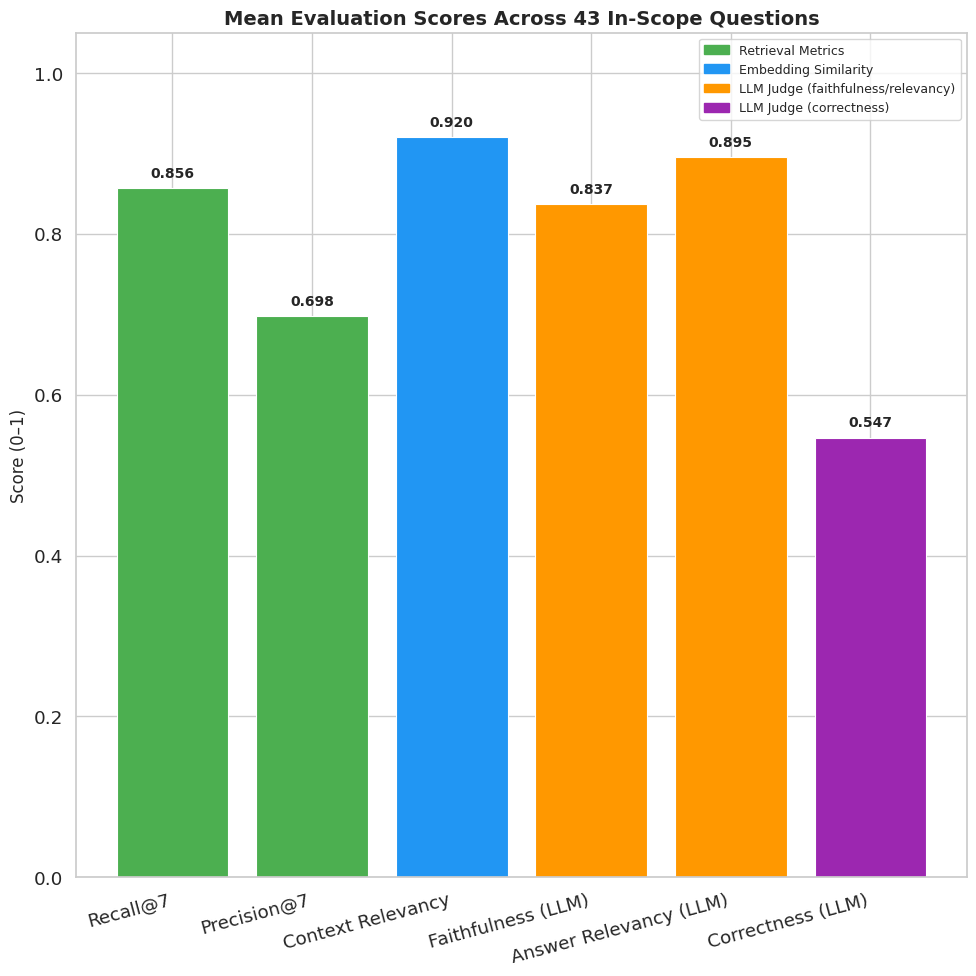


 Mean Scores Comparison:
--------------------------------------------------
Metric                         In-Scope     All Qs      
--------------------------------------------------
Recall@7                       0.856         0.695
Precision@7                    0.698         0.650
Context Relevancy              0.920         0.920
Faithfulness (LLM)             0.837         0.868
Answer Relevancy (LLM)         0.895         0.915
Correctness (LLM)              0.547         0.547


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Filter out out-of-scope questions for the graph
df_in_scope = df_final[df_final["difficulty"] != "out-of-scope"].copy()

# Calculate means only for in-scope questions
plot_cols = ["Recall@7", "Precision@7", "Context Relevancy",
             "Faithfulness (LLM)", "Answer Relevancy (LLM)", "Correctness (LLM)"]
means = df_in_scope[plot_cols].mean()

colors = ["#4CAF50", "#4CAF50", "#2196F3", "#FF9800", "#FF9800", "#9C27B0"]
fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.bar(means.index, means.values, color=colors, edgecolor="white", linewidth=0.8)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score (0–1)", fontsize=12)
ax.set_title(f"Mean Evaluation Scores Across {len(df_in_scope)} In-Scope Questions",
             fontsize=14, fontweight="bold")

for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

legend = [
    mpatches.Patch(color="#4CAF50", label="Retrieval Metrics"),
    mpatches.Patch(color="#2196F3", label="Embedding Similarity"),
    mpatches.Patch(color="#FF9800", label="LLM Judge (faithfulness/relevancy)"),
    mpatches.Patch(color="#9C27B0", label="LLM Judge (correctness)"),
]
ax.legend(handles=legend, fontsize=9)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("metric_scores_in_scope.png", dpi=150)
plt.show()

# Optional: Also show comparison with out-of-scope included
print("\n Mean Scores Comparison:")
print("-" * 50)
print(f"{'Metric':<30} {'In-Scope':<12} {'All Qs':<12}")
print("-" * 50)
for col in means.index:
    in_scope_val = means[col]
    all_val = df_final[col].mean()
    print(f"{col:<30} {in_scope_val:.3f}         {all_val:.3f}")

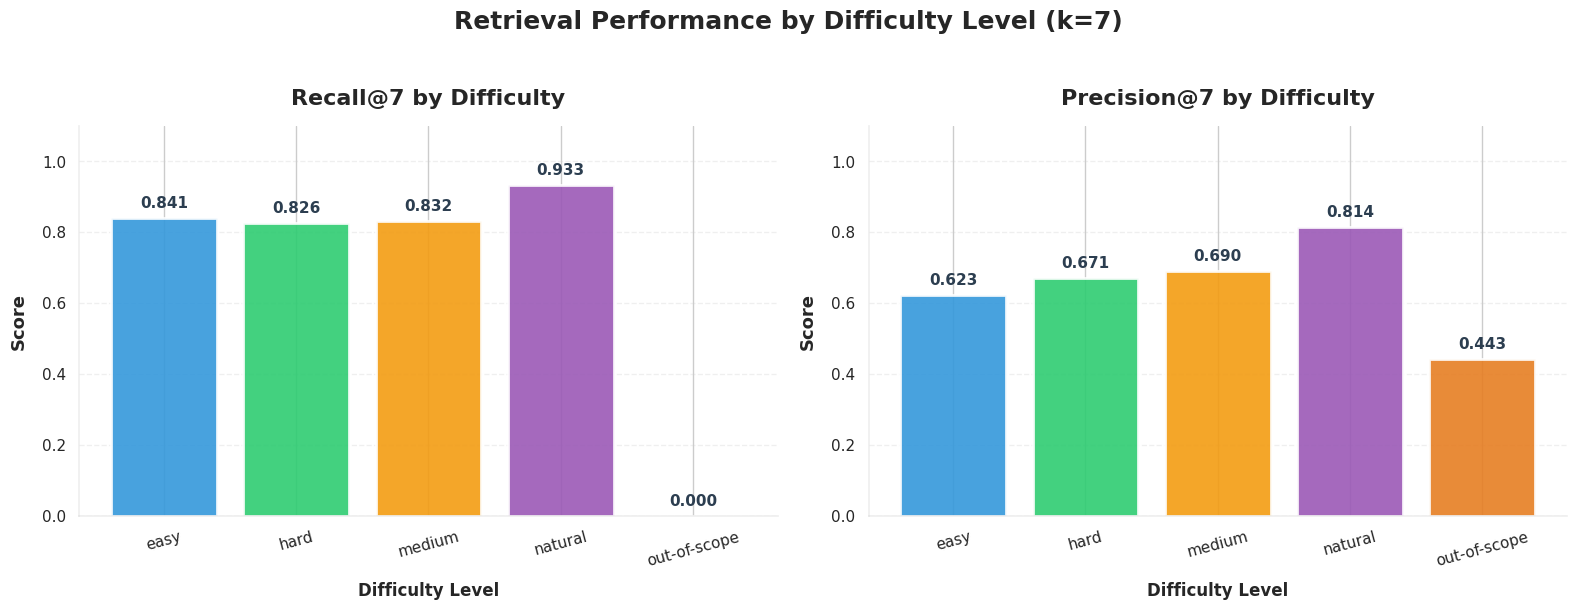

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set up the aesthetics
sns.set_style("whitegrid")
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

# Prepare the data
difficulty_means = df_final.groupby('difficulty')[['Recall@7', 'Precision@7']].mean().reset_index()
difficulties = difficulty_means['difficulty'].tolist()
recall_vals = difficulty_means['Recall@7'].tolist()
precision_vals = difficulty_means['Precision@7'].tolist()

# Create a beautiful figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colors - using a nice gradient
recall_color = '#3498db'  # Blue
precision_color = '#e74c3c'  # Red
bar_colors = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e67e22']

# Recall subplot
ax = axes[0]
bars1 = ax.bar(difficulties, recall_vals, color=bar_colors[:len(difficulties)],
               edgecolor='white', linewidth=2, alpha=0.9)

# Add value labels on bars
for bar, val in zip(bars1, recall_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='#2c3e50')

ax.set_title("Recall@7 by Difficulty", fontweight="bold", fontsize=16, pad=15)
ax.set_ylabel("Score", fontsize=13, fontweight='semibold', labelpad=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)


# Precision subplot
ax = axes[1]
bars2 = ax.bar(difficulties, precision_vals, color=bar_colors[:len(difficulties)],
               edgecolor='white', linewidth=2, alpha=0.9)

# Add value labels on bars
for bar, val in zip(bars2, precision_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='#2c3e50')

ax.set_title("Precision@7 by Difficulty", fontweight="bold", fontsize=16, pad=15)
ax.set_ylabel("Score", fontsize=13, fontweight='semibold', labelpad=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Main title
plt.suptitle("Retrieval Performance by Difficulty Level (k=7)",
             fontsize=18, fontweight="bold", y=1.02)

# Add some styling
for ax in axes:
    ax.set_xlabel("Difficulty Level", fontsize=12, fontweight='semibold', labelpad=10)
    ax.tick_params(axis='x', rotation=15, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_alpha(0.3)
    ax.spines['bottom'].set_alpha(0.3)

plt.tight_layout()
plt.savefig("recall_precision_beautiful.png", dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

---

## Section 6. Web Deployment

The chatbot is deployed as an interactive web application using **Gradio**. The interface allows users to type natural language questions and receive answers grounded in the childcare disease handbook, with retrieved source chunks displayed in a side panel.

### Interface Features
- **Chat interface**: Conversational Q&A with message history
- **Retrieved context panel**: Displays the top-7 source chunks used to generate each answer
- **Example questions**: Pre-loaded examples for quick exploration
- **Real-time generation**: Responses generated live using Falcon-7B-Instruct

### Access
The application was deployed via Gradio's public sharing feature (`share=True`), generating a public URL accessible from any device without local installation.

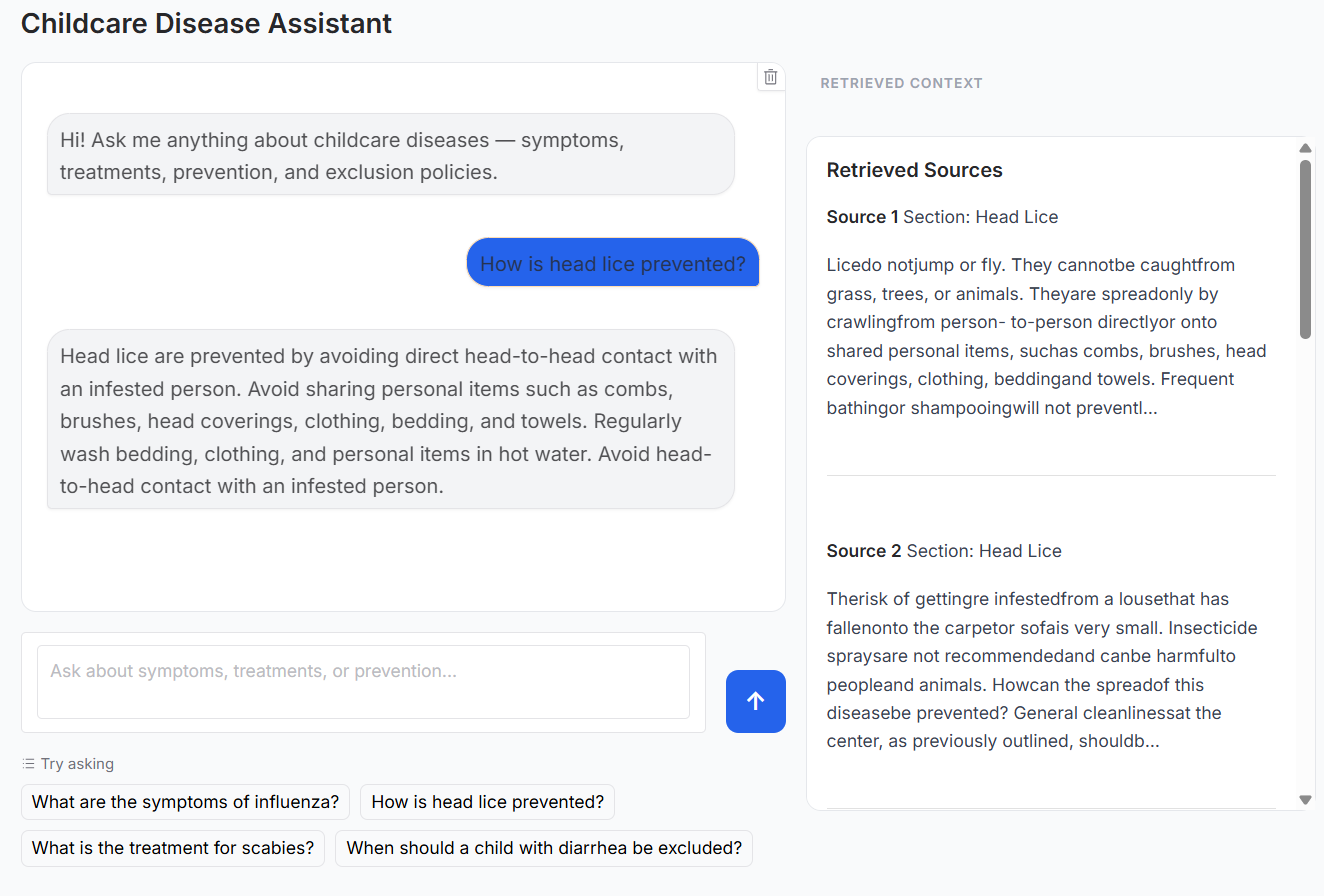



In [ ]:
SCOPE_CHECK_PROMPT = """You are a scope checker for a childcare disease handbook chatbot.
The handbook covers communicable diseases in childcare settings: symptoms, transmission, treatment, prevention, and exclusion policies.

Question: {question}

Is this question answerable from a childcare disease handbook?
Respond ONLY with valid JSON: {{"in_scope": true}} or {{"in_scope": false}}"""

def is_in_scope(question: str) -> bool:
    """Use LLM to check if question is relevant to childcare diseases."""
    try:
        response = client.chat.completions.create(
            model=GROQ_MODEL,
            messages=[{"role": "user", "content": SCOPE_CHECK_PROMPT.format(question=question)}],
            temperature=0.0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip()
        raw = re.sub(r"```(?:json)?", "", raw).strip().rstrip("```").strip()
        result = json.loads(raw)
        return result.get("in_scope", True)
    except Exception:
        return True  # fail open — better to answer than wrongly block

def rag_query(question: str, top_k: int = 7) -> dict:
    retrieved = retrieve_context(question, top_k=top_k)

    # ── Guard: LLM scope check ──
    if not is_in_scope(question):
        return {
            "answer": "I'm sorry, I don't have information about that in the childcare disease handbook. Please consult a healthcare provider for further guidance.",
            "context": retrieved
        }

    answer = generate_answer(question, retrieved)
    return {
        "answer": answer,
        "context": retrieved
    }

print("✓ rag_query function defined")

import gradio as gr

custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600&display=swap');
* { font-family: 'Inter', sans-serif !important; }

body, .gradio-container {
    background: #f9fafb !important;
    max-width: 1100px !important;
    margin: 0 auto !important;
}

#chatbot {
    height: 440px !important;
    border-radius: 12px !important;
    border: 1px solid #e5e7eb !important;
    background: white !important;
}
#chatbot .user {
    background: #2563eb !important;
    color: white !important;
    border-radius: 18px 18px 4px 18px !important;
    font-size: 14px !important;
}
#chatbot .bot {
    background: #f3f4f6 !important;
    color: #111827 !important;
    border-radius: 18px 18px 18px 4px !important;
    font-size: 14px !important;
}

#send-btn {
    background: #2563eb !important;
    color: white !important;
    border-radius: 10px !important;
    border: none !important;
    font-size: 20px !important;
    min-width: 48px !important;
    max-width: 48px !important;
    align-self: flex-end !important;
    cursor: pointer !important;
    padding: 10px 0 !important;
}
#send-btn:hover { background: #1d4ed8 !important; }

#context-panel {
    height: 540px !important;
    overflow-y: auto !important;
    border-radius: 12px !important;
    border: 1px solid #e5e7eb !important;
    background: white !important;
    padding: 16px !important;
    font-size: 13px !important;
    color: #374151 !important;
    line-height: 1.6 !important;
}
#context-panel p { color: #374151 !important; }

.panel-label {
    font-size: 11px !important;
    font-weight: 600 !important;
    color: #9ca3af !important;
    text-transform: uppercase !important;
    letter-spacing: 0.8px !important;
    margin-bottom: 8px !important;
    display: block;
}

footer, .built-with { display: none !important; }
"""

def user_message(message, history):
    """Step 1 — immediately show user message, clear input."""
    if not message.strip():
        return history, message
    history = history + [(message, None)]
    return history, ""

def bot_response(history):
    """Step 2 — generate answer and fill in the None placeholder."""
    if not history or history[-1][1] is not None:
        return history, "*Ask a question to see sources.*"

    question = history[-1][0]
    result = rag_query(question)
    answer = result["answer"] if result["answer"].strip() else "I'm sorry, I could not find relevant information in the handbook for that question."

    history[-1] = (question, answer)

    ctx_md = "### Retrieved Sources\n\n"
    for i, chunk in enumerate(result["context"], 1):
        preview = chunk.replace("Section: General\n\n", "").strip()[:300]
        ctx_md += f"**Source {i}**\n{preview}...\n\n---\n\n"

    return history, ctx_md

with gr.Blocks(css=custom_css, title="MedRAG") as demo:

    gr.Markdown("##  Childcare Disease Assistant")

    with gr.Row(equal_height=False):
        with gr.Column(scale=3):
            chatbot = gr.Chatbot(
                elem_id="chatbot",
                show_label=False,
                bubble_full_width=False,
                value=[(None, "Hi! Ask me anything about childcare diseases — symptoms, treatments, prevention, and exclusion policies.")]
            )
            with gr.Row():
                msg_input = gr.Textbox(
                    placeholder="Ask about symptoms, treatments, or prevention...",
                    show_label=False,
                    lines=2,
                    max_lines=5,
                    scale=10
                )
                send_btn = gr.Button("↑", elem_id="send-btn", scale=1)

            gr.Examples(
                examples=[
                    ["What are the symptoms of influenza?"],
                    ["How is head lice prevented?"],
                    ["What is the treatment for scabies?"],
                    ["When should a child with diarrhea be excluded?"],
                ],
                inputs=msg_input,
                label="Try asking"
            )

        with gr.Column(scale=2):
            gr.HTML('<span class="panel-label">Retrieved Context</span>')
            context_display = gr.Markdown(
                value="*Ask a question to see the sources used to generate the answer.*",
                elem_id="context-panel"
            )

    send_btn.click(
        user_message, [msg_input, chatbot], [chatbot, msg_input]
    ).then(
        bot_response, [chatbot], [chatbot, context_display]
    )
    msg_input.submit(
        user_message, [msg_input, chatbot], [chatbot, msg_input]
    ).then(
        bot_response, [chatbot], [chatbot, context_display]
    )

demo.launch(share=True)

✓ rag_query function defined


/tmp/ipykernel_605/1712230677.py:139: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, title="MedRAG") as demo:
/tmp/ipykernel_605/1712230677.py:145: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot = gr.Chatbot(
/tmp/ipykernel_605/1712230677.py:145: DeprecationWarning: The 'bubble_full_width' parameter will be removed in Gradio 6.0. This parameter no longer has any effect.
  chatbot = gr.Chatbot(
/tmp/ipykernel_605/1712230677.py:145: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_ta

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://33f0fa98cdcb699a12.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
